# Analyse Exploratoire

### Import des modules

In [1]:
#exploration
import pandas as pd
import numpy as np
#titles for graphs
from IPython.display import display, Markdown
#visualisation
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

### Analyse Exploratoire

In [2]:
#import the data
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [3]:
def title(text):
    display(Markdown(f'### {text}'))

#let's get basic info about the data
title('Overview')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
display(building_consumption)        # first and last 5 rows - get a feel for the data

title('Statistics')
display(building_consumption.describe())    # stats for numeric columns (mean, min, max...)

title('Info')
building_consumption.info()                 # column types + non-null counts

title('Nulls per column')
nulls = building_consumption.isnull().sum()
display(nulls[nulls > 0])               # null count per column


title('Duplicate Rows')
display(building_consumption.duplicated().sum())          # number of duplicate rows


title('Distinct Values per Column')
display(building_consumption.nunique())                   # distinct values per column

title('Correlation Matrix')
corr_matrix = building_consumption.corr(numeric_only=True) #correlation matrix for all numeric columns

# Keep only correlations >= 0.5 (or <= -0.5 for negative ones)
corr_mask = (corr_matrix.abs() >= 0.5) & ~np.eye(len(corr_matrix), dtype=bool)
filtered = corr_matrix.where(corr_mask).dropna(how='all').dropna(axis=1, how='all')

display(filtered.fillna(''))

### Overview

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,Office,12294.0,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recreation, Swimming Pool",Other - Recreation,7583.0,Fitness Center/Health Club/Gy

### Statistics

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


### Info

...

np.int64(0)

### Distinct Values per Column

OSEBuildingID                      3376
DataYear                              1
BuildingType                          8
PrimaryPropertyType                  24
PropertyName                       3362
Address                            3354
City                                  1
State                                 1
ZipCode                              55
TaxParcelIdentificationNumber      3268
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           2876
Longitude                          2656
YearBuilt                           113
NumberofBuildings                    17
NumberofFloors                       50
PropertyGFATotal                   3195
PropertyGFAParking                  496
PropertyGFABuilding(s)             3193
ListOfAllPropertyUseTypes           466
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          3122
SecondLargestPropertyUseType         50
SecondLargestPropertyUseTypeGFA    1352


### Correlation Matrix

,NumberofBuildings,PropertyGFATotal,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
NumberofBuildings,,0.693412,0.730487,0.758749,,,,,,,0.690712,,,0.735028,0.735028,,,,
PropertyGFATotal,0.693412,,0.989823,0.974113,0.807411,0.519872,,,,,0.796781,,,0.849576,0.849576,,,0.531436,
PropertyGFABuilding(s),0.730487,0.989823,,0.978422,0.791727,0.539486,,,,,0.811866,,,0.859833,0.859833,,,0.545503,
LargestPropertyUseTypeGFA,0.758749,0.974113,0.978422,,0.769156,,,,,,0.836185,,,0.875059,0.875059,,,0.578487,
SecondLargestPropertyUseTypeGFA,,0.807411,0.791727,0.769156,,0.66228,,,,,0.630121,0.626631,,0.634493,0.634493,,,0.506537,
ThirdLargestPropertyUseTypeGFA,,0.519872,0.539486,,0.66228,,,,,,0.754093,0.753857,,0.683477,0.683477,0.647532,0.647532,0.677722,
SiteEUI(kBtu/sf),,,,,,,,0.993549,0.944141,0.940204,,,,,,,,,0.730897
SiteEUIWN(kBtu/sf),,,,,,,0.993549,,0.930434,0.938051,,,,,,,,,0.745573
SourceEUI(kBtu/sf),,,,,,,0.944141,0.930434,,0.994317,,,,,,,,,0.524232
SourceEUIWN(kBtu/sf),,,,,,,0.940204,0.938051,0.994317,,,,,,,,,,0.529583


#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

In [4]:
#What are the building types?
df_display = pd.DataFrame({
    'count': building_consumption['BuildingType'].value_counts(dropna=False),
    'percentage': building_consumption['BuildingType'].value_counts(normalize=True).map('{:.1%}'.format)
}).reset_index().rename(columns={'index': 'BuildingType'})

total = pd.DataFrame([{'BuildingType': 'Total', 'count': df_display['count'].sum(), 'percentage': '100%'}])
df_display = pd.concat([df_display, total], ignore_index=True)

df_display.index = list(range(1, len(df_display))) + ['']  # empty index for total row

display(df_display.style.apply(
    lambda x: ['font-weight: bold' if x.name == '' else '' for _ in x], axis=1
))

#visualize the distribution of building types
counts = building_consumption["BuildingType"].value_counts().reset_index()
counts.columns = ['BuildingType', 'count']
counts['percentage'] = counts['count'] / counts['count'].sum()

# Use plotly's default color sequence
colors = px.colors.qualitative.Plotly[:len(counts)]

fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'xy'}]])

# Pie chart - show only percentage
fig.add_trace(go.Pie(
    labels=counts['BuildingType'], 
    values=counts['percentage'],
    textinfo='label+percent',        # show labe and percentage
    hovertemplate='%{label}<br>Count: %{customdata}<br>Percentage: %{percent}<extra></extra>',
customdata=counts['count'],
    marker=dict(colors=colors)
), row=1, col=1)

# Bar chart - same colors as pie
fig.add_trace(go.Bar(
    x=counts['BuildingType'], 
    y=counts['percentage'],
    marker=dict(color=colors),
    hovertemplate='%{x}<br>Count: %{customdata}<br>Percentage: %{y:.1%}<extra></extra>',
customdata=counts['count'],
    showlegend=False
), row=1, col=2)

fig.update_layout(yaxis=dict(tickformat='.0%'), title='Building Types')

fig.show()

,BuildingType,count,percentage
1,NonResidential,1460,43.2%
2,Multifamily LR (1-4),1018,30.2%
3,Multifamily MR (5-9),580,17.2%
4,Multifamily HR (10+),110,3.3%
5,SPS-District K-12,98,2.9%
6,Nonresidential COS,85,2.5%
7,Campus,24,0.7%
8,Nonresidential WA,1,0.0%
,Total,3376,100%


In [5]:
#What's the primary property type for...
def show_property_types(building_type):
    title(building_type)
    
    filtered = building_consumption[
        building_consumption['BuildingType'].str.contains(building_type, case=False)
    ]
    
    counts = filtered['PrimaryPropertyType'].value_counts().reset_index()
    counts.columns = ['PrimaryPropertyType', 'count']
    counts['percentage'] = counts['count'] / counts['count'].sum()

    # Table - full data
    table = counts.copy()
    table['percentage'] = table['percentage'].map('{:.1%}'.format)
    total = pd.DataFrame([{'PrimaryPropertyType': 'Total', 'count': table['count'].sum(), 'percentage': '100%'}])
    table = pd.concat([table, total], ignore_index=True)
    table.index = list(range(1, len(table))) + ['']
    display(table.style.apply(
        lambda x: ['font-weight: bold'] * len(x) if x.name == '' else [''] * len(x), axis=1
    ))

    # Charts - group into "More" if more than 10 types
    chart_counts = counts.copy()
    if len(chart_counts) > 10:
        top = chart_counts.head(9)
        other = pd.DataFrame([{'PrimaryPropertyType': 'More', 'count': chart_counts.iloc[9:]['count'].sum(), 'percentage': chart_counts.iloc[9:]['percentage'].sum()}])
        chart_counts = pd.concat([top, other], ignore_index=True)

    colors = px.colors.qualitative.Plotly[:len(chart_counts)]
    fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'xy'}]])

    fig.add_trace(go.Pie(
        labels=chart_counts['PrimaryPropertyType'],
        values=chart_counts['percentage'],
        textinfo='label+percent',
        hovertemplate='%{label}<br>Count: %{customdata}<br>Percentage: %{percent}<extra></extra>',
        customdata=chart_counts['count'],
        marker=dict(colors=colors)
    ), row=1, col=1)

    fig.add_trace(go.Bar(
        x=chart_counts['PrimaryPropertyType'],
        y=chart_counts['percentage'],
        marker=dict(color=colors),
        hovertemplate='%{x}<br>Count: %{customdata}<br>Percentage: %{y:.1%}<extra></extra>',
        customdata=chart_counts['count'],
        showlegend=False
    ), row=1, col=2)

    fig.update_layout(yaxis=dict(tickformat='.0%'), title=building_type)
    fig.show()

show_property_types('SPS-District K-12') #SPS-District K-12 buildings?
show_property_types('Campus') #Campus buildings?
show_property_types('nonresidential') #non-residential buildings?

### SPS-District K-12

,PrimaryPropertyType,count,percentage
1,K-12 School,96,98.0%
2,Other,2,2.0%
,Total,98,100%


### Campus

,PrimaryPropertyType,count,percentage
1,Other,7,29.2%
2,University,6,25.0%
3,Mixed Use Property,4,16.7%
4,K-12 School,4,16.7%
5,Large Office,1,4.2%
6,Low-Rise Multifamily,1,4.2%
7,Restaurant,1,4.2%
,Total,24,100%


### nonresidential

,PrimaryPropertyType,count,percentage
1,Small- and Mid-Sized Office,292,18.9%
2,Other,241,15.6%
3,Warehouse,187,12.1%
4,Large Office,172,11.1%
5,Mixed Use Property,110,7.1%
6,Retail Store,91,5.9%
7,Hotel,76,4.9%
8,Worship Facility,71,4.6%
9,Distribution Center,53,3.4%
10,Supermarket / Grocery Store,40,2.6%


# Target values are
**SiteEnergyUse(kBtu)** — total energy consumption

**TotalGHGEmissions** — CO2 emissions

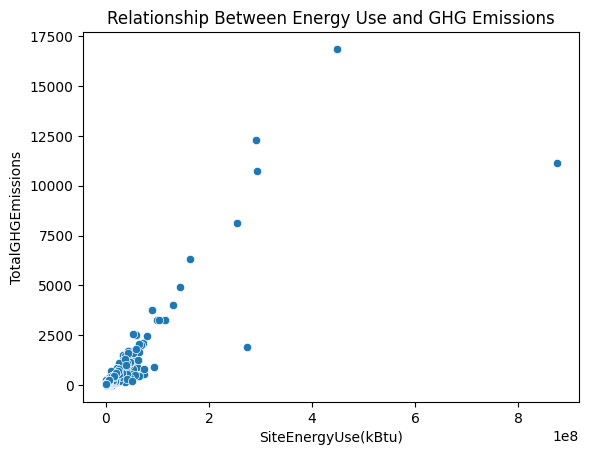

In [6]:
sns.scatterplot(x=building_consumption['SiteEnergyUse(kBtu)'], y=building_consumption['TotalGHGEmissions'])
plt.title("Relationship Between Energy Use and GHG Emissions")
plt.show()

# Data Cleaning

Let's keep only non-residetial buildings

In [7]:
TARGETS = ['SiteEnergyUse(kBtu)', 'TotalGHGEmissions']

mask = building_consumption['BuildingType'].str.contains(
    'SPS-District K-12|Campus|nonresidential', case=False
)
df = building_consumption[mask]

### What other columns we don't need?

Actually we shouldn't consider administrative data,
the project brief says to consider only structural info so we'll drop this column.
Let's drop all the columns that we don't need

In [8]:
#DataYear is always 2016, so we can drop it
df = df.drop(columns=['DataYear'])

#City and State are always the same, so we drop them too
df = df.drop(columns=['City', 'State'])

#Address and PropertyName are descriptive, not structural, so we drop them
df = df.drop(columns=['Address', 'PropertyName', 'TaxParcelIdentificationNumber', 'ComplianceStatus', 'OSEBuildingID', 'DefaultData'])

#Comments are all null, so we drop that too
df = df.drop(columns=['Comments'])

#Redundant since we have it in single columns
df = df.drop(columns=['ListOfAllPropertyUseTypes'])


#Let's drop the columns derived from energy
df = df.drop(columns=[
    # Energy sub-components (sum up to target)
    'Electricity(kWh)', 'Electricity(kBtu)',
    'NaturalGas(therms)', 'NaturalGas(kBtu)',
    'SteamUse(kBtu)',

    # Derived from target
    'SiteEnergyUseWN(kBtu)',
    'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',

    # Derived from CO2 target
    'GHGEmissionsIntensity'
])


In [9]:
df.corr(numeric_only=True)['SiteEnergyUse(kBtu)'].sort_values(ascending=False)

SiteEnergyUse(kBtu)                1.000000
TotalGHGEmissions                  0.859940
LargestPropertyUseTypeGFA          0.841987
PropertyGFABuilding(s)             0.819630
PropertyGFATotal                   0.804162
ThirdLargestPropertyUseTypeGFA     0.764750
NumberofBuildings                  0.712977
SecondLargestPropertyUseTypeGFA    0.631359
NumberofFloors                     0.220100
PropertyGFAParking                 0.146116
YearBuilt                          0.062774
CouncilDistrictCode                0.048573
Longitude                          0.033358
Latitude                           0.009321
ZipCode                           -0.049862
ENERGYSTARScore                   -0.080135
Name: SiteEnergyUse(kBtu), dtype: float64

In [10]:
#What are the outlier values?
df_display = pd.DataFrame({
    'count': df['Outlier'].value_counts(dropna=False),
    'percentage': df['Outlier'].value_counts(normalize=True).map('{:.1%}'.format)
}).reset_index().rename(columns={'index': 'Outlier'})

total = pd.DataFrame([{'Outlier': 'Total', 'count': df_display['count'].sum(), 'percentage': '100%'}])
df_display = pd.concat([df_display, total], ignore_index=True)

df_display.index = list(range(1, len(df_display))) + ['']  # empty index for total row

display(df_display.style.apply(
    lambda x: ['font-weight: bold' if x.name == '' else '' for _ in x], axis=1
))

,Outlier,count,percentage
1,High outlier,2,11.8%
2,Low outlier,15,88.2%
3,nan,1651,nan
,Total,1668,100%


only 17 building out of 1668 are outliers.
That's about 1% of our data.
Since they are markes us suspicious, let's drop them.Since bad input data will hurt our model more than
losing 17rows

In [11]:
df = df[df['Outlier'].isna()].drop(columns='Outlier')

Let's look at the current view of our dataframe

In [12]:
#let's get basic info about the data
title('Overview')
display(df)        # first and last 5 rows - get a feel for the data

title('Statistics')
display(df.describe())    # stats for numeric columns (mean, min, max...)

title('Info')
df.info()                 # column types + non-null counts

title('Nulls per column')
nulls = df.isnull().sum()
display(nulls[nulls > 0])              # null count per column


title('Duplicate Rows')
display(df.duplicated().sum())          # number of duplicate rows


title('Distinct Values per Column')
display(df.nunique())                   # distinct values per column

### Overview

,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,7.226362e+06,249.98
1,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,8.387933e+06,295.86
2,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,7.258702e+07,2089.28
3,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,6.794584e+06,286.43
4,NonResidential,Hotel,98121.0,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,1.417261e+07,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,Nonresidential COS,Office,NaN,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1.0,1,12294,0,12294,Office,12294.0,NaN,NaN,NaN,NaN,NaN,46.0,8.497457e+05,20.94
3372,Nonresidential COS,Other,NaN,2,DOWNTOWN,47.59625,-122.32283,2004,1.0,1,16000,0,16000,Other - Recreation,16000.0,NaN,NaN,NaN,NaN,NaN,NaN,9.502762e+05,32.17
3373,Nonresidential COS,Other,NaN,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1.0,1,13157,0,13157,Other - Recreation,7583.0,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,NaN,5.765898e+06,223.54
3374,Nonresidential COS,Mixed Use Property,NaN,1,GREATER DUWAMISH,47.52832,-122.32431,1989,1.0,1,14101,0,14101,Other - Recreation,6601.0,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,NaN,7.194712e+05,22.11


### Statistics

,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
count,1635.000000,1651.000000,1651.000000,1651.000000,1651.000000,1649.000000,1651.000000,1.651000e+03,1651.000000,1.651000e+03,1.645000e+03,848.000000,351.000000,1083.000000,1.649000e+03,1649.000000
mean,98116.852599,4.359176,47.616207,-122.332926,1962.156269,1.167981,4.135675,1.194803e+05,12989.345245,1.064910e+05,9.929920e+04,36981.157190,14923.334469,65.191136,8.475041e+06,186.500079
std,18.482011,2.190338,0.048258,0.024601,32.632663,2.944930,6.593459,2.987860e+05,42466.370785,2.855922e+05,2.780532e+05,70088.777826,36887.605015,28.376486,3.037542e+07,755.634975
min,98006.000000,1.000000,47.499170,-122.411820,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000e+00,-0.800000
25%,98105.000000,2.000000,47.585445,-122.343300,1930.000000,1.000000,1.000000,2.951650e+04,0.000000,2.851550e+04,2.564900e+04,5406.000000,2649.000000,48.000000,1.252324e+06,20.480000
50%,98109.000000,4.000000,47.612440,-122.332890,1966.000000,1.000000,2.000000,4.974400e+04,0.000000,4.756000e+04,4.407800e+04,12011.500000,5931.000000,73.000000,2.582687e+06,49.980000
75%,98125.000000,7.000000,47.649760,-122.321745,1989.000000,1.000000,4.000000,1.060205e+05,0.000000,9.518700e+04,9.212900e+04,31863.000000,12670.500000,89.000000,6.917478e+06,144.410000
max,98199.000000,7.000000,47.733870,-122.258640,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,8.739237e+08,16870.980000


### Info

...

ZipCode                              16
NumberofBuildings                     2
LargestPropertyUseType                6
LargestPropertyUseTypeGFA             6
SecondLargestPropertyUseType        803
SecondLargestPropertyUseTypeGFA     803
ThirdLargestPropertyUseType        1300
ThirdLargestPropertyUseTypeGFA     1300
YearsENERGYSTARCertified           1553
ENERGYSTARScore                     568
SiteEnergyUse(kBtu)                   2
TotalGHGEmissions                     2
dtype: int64

### Duplicate Rows

np.int64(0)

### Distinct Values per Column

BuildingType                          5
PrimaryPropertyType                  22
ZipCode                              48
CouncilDistrictCode                   7
Neighborhood                         19
Latitude                           1482
Longitude                          1396
YearBuilt                           113
NumberofBuildings                    16
NumberofFloors                       45
PropertyGFATotal                   1574
PropertyGFAParking                  325
PropertyGFABuilding(s)             1569
LargestPropertyUseType               56
LargestPropertyUseTypeGFA          1547
SecondLargestPropertyUseType         47
SecondLargestPropertyUseTypeGFA     697
ThirdLargestPropertyUseType          39
ThirdLargestPropertyUseTypeGFA      301
YearsENERGYSTARCertified             64
ENERGYSTARScore                     100
SiteEnergyUse(kBtu)                1634
TotalGHGEmissions                  1578
dtype: int64

Let's decide what to do with missing values

In [13]:
#let's see the rows where NumberofBuildings is null
display(df[df['NumberofBuildings'].isnull()])

,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
578,NonResidential,Small- and Mid-Sized Office,98104.0,7,DOWNTOWN,47.60380,-122.33293,1924,NaN,4,63150,0,63150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2670,NonResidential,Mixed Use Property,98105.0,4,NORTHEAST,47.66182,-122.31345,1928,NaN,2,20760,0,20760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


they have a lot of missing data and will be dropped in the next code block since our target values are null there

In [14]:
#drop the rows when a column has a small amount of nulls
df = df.dropna(subset=[
    'SiteEnergyUse(kBtu)', #2
    'TotalGHGEmissions', #2
    'ZipCode', #16
    'LargestPropertyUseType', #6
    'LargestPropertyUseTypeGFA'#6
])

#drop columns with a large amount of nulls
df = df.drop(columns=['YearsENERGYSTARCertified']) # 1553 out of 1651

#fill columns with meaningful absence
df[['SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']] = df[['SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']].fillna('None')
df[['SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']] = df[['SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA']].fillna(0)

In [15]:
negative_ghg_rows = df[df['TotalGHGEmissions'] < 0]
negative_ghg_rows

,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
3206,NonResidential,Small- and Mid-Sized Office,98122.0,3,CENTRAL,47.61432,-122.31257,2013,1.0,6,52000,0,52000,Office,48159.0,None,0.0,None,0.0,100.0,342726.0938,-0.8


In [16]:
# Remove rows with negative GHG emissions (likely data errors)
df = df[df['TotalGHGEmissions'] >= 0]

# Let's see what to do with ENERGYSTARScore since it has a lot of nulls

In [17]:
#check if it's correlated with the targets
print(df['ENERGYSTARScore'].corr(df['SiteEnergyUse(kBtu)']))
print(df['ENERGYSTARScore'].corr(df['TotalGHGEmissions']))

-0.07569240781192958
-0.10652856128328367


Correlations are close to 0, so very weak.
Plus this columns is based on energy use, so it's partially derived from energy consumption (our taget).
Therefore it's a potential data leakage problem, similar to why we dropped SiteEUI.
Hence let's drop it

In [18]:
#keep it for later use (to compare the model score with and without it)
energystar_column = df['ENERGYSTARScore'].copy()
#drop it
df = df.drop(columns=['ENERGYSTARScore'])

Let's look at the current state of our df

In [19]:
#let's get basic info about the data
title('Overview')
display(df)        # first and last 5 rows - get a feel for the data

title('Statistics')
display(df.describe())    # stats for numeric columns (mean, min, max...)

title('Info')
df.info()                 # column types + non-null counts

title('Nulls per column')
nulls = df.isnull().sum()
display(nulls[nulls > 0])              # null count per column


title('Duplicate Rows')
display(df.duplicated().sum())          # number of duplicate rows


title('Distinct Values per Column')
display(df.nunique())                   # distinct values per column

### Overview

,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,88434.0,None,0.0,None,0.0,7226362.50,249.98
1,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,8387933.00,295.86
2,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,756493.0,None,0.0,None,0.0,72587024.00,2089.28
3,NonResidential,Hotel,98101.0,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,61320.0,None,0.0,None,0.0,6794584.00,286.43
4,NonResidential,Hotel,98121.0,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,14172606.00,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3339,NonResidential,Small- and Mid-Sized Office,98108.0,2,GREATER DUWAMISH,47.53161,-122.29944,1929,1.0,2,24990,0,24990,Office,24990.0,None,0.0,None,0.0,4420650.50,134.80
3340,NonResidential,Other,98155.0,4,NORTHEAST,47.68109,-122.26180,2013,1.0,1,72000,0,72000,Other - Recreation,72000.0,None,0.0,None,0.0,2925780.00,67.65
3347,NonResidential,K-12 School,98144.0,3,GREATER DUWAMISH,47.58831,-122.30650,2015,1.0,3,45000,0,45000,K-12 School,45728.0,Parking,0.0,None,0.0,1325972.75,9.24
3356,NonResidential,Mixed Use Property,98109.0,7,LAKE UNION,47.62497,-122.33883,2015,1.0,6,345290,85028,260262,Laboratory,151523.0,Office,106498.0,Parking,84002.0,39364116.00,1000.06


### Statistics

,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),TotalGHGEmissions
count,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1628.000000,1.628000e+03,1.628000e+03,1628.000000,1628.000000,1.628000e+03,1628.000000
mean,98116.884521,4.363022,47.616115,-122.332911,1962.114865,1.169533,4.166462,1.207776e+05,13172.855651,1.076048e+05,1.001873e+05,19235.232983,3212.919778,8.559162e+06,188.135012
std,18.508363,2.192132,0.048188,0.024462,32.577849,2.963744,6.631206,3.006762e+05,42737.189556,2.874348e+05,2.793637e+05,53849.312367,18177.395953,3.056095e+07,760.305856
min,98006.000000,1.000000,47.499170,-122.411820,1900.000000,0.000000,0.000000,1.630000e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,0.000000e+00,0.000000
25%,98105.000000,2.000000,47.585385,-122.343280,1930.000000,1.000000,1.000000,3.006625e+04,0.000000,2.880000e+04,2.587900e+04,0.000000,0.000000,1.264034e+06,20.600000
50%,98109.000000,4.000000,47.612420,-122.332920,1966.000000,1.000000,2.000000,5.007400e+04,0.000000,4.799650e+04,4.470300e+04,0.000000,0.000000,2.603072e+06,50.435000
75%,98125.000000,7.000000,47.649752,-122.321793,1989.000000,1.000000,4.000000,1.080882e+05,0.000000,9.638250e+04,9.306950e+04,12924.000000,0.000000,7.007642e+06,144.870000
max,98199.000000,7.000000,47.733870,-122.258640,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,8.739237e+08,16870.980000


### Info

...

Series([], dtype: int64)

### Duplicate Rows

np.int64(0)

### Distinct Values per Column

BuildingType                          5
PrimaryPropertyType                  21
ZipCode                              48
CouncilDistrictCode                   7
Neighborhood                         18
Latitude                           1464
Longitude                          1376
YearBuilt                           113
NumberofBuildings                    16
NumberofFloors                       45
PropertyGFATotal                   1553
PropertyGFAParking                  325
PropertyGFABuilding(s)             1548
LargestPropertyUseType               55
LargestPropertyUseTypeGFA          1531
SecondLargestPropertyUseType         48
SecondLargestPropertyUseTypeGFA     691
ThirdLargestPropertyUseType          40
ThirdLargestPropertyUseTypeGFA      295
SiteEnergyUse(kBtu)                1613
TotalGHGEmissions                  1560
dtype: int64

In [20]:
#Let's change some of the column types
#these are categories so they are strings not numbers
df['ZipCode'] = df['ZipCode'].astype(int).astype(str)
df['CouncilDistrictCode'] = df['CouncilDistrictCode'].astype(str)
#int since it's a count
df['NumberofBuildings'] = df['NumberofBuildings'].astype(int)

In [21]:
#let's check the result
title('Overview')
display(df)        # first and last 5 rows - get a feel for the data

title('Statistics')
display(df.describe())    # stats for numeric columns (mean, min, max...)

title('Info')
df.info()                 # column types + non-null counts

title('Nulls per column')
nulls = df.isnull().sum()
display(nulls[nulls > 0])              # null count per column


title('Duplicate Rows')
display(df.duplicated().sum())          # number of duplicate rows


title('Distinct Values per Column')
display(df.nunique())                   # distinct values per column

### Overview

,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101,7,DOWNTOWN,47.61220,-122.33799,1927,1,12,88434,0,88434,Hotel,88434.0,None,0.0,None,0.0,7226362.50,249.98
1,NonResidential,Hotel,98101,7,DOWNTOWN,47.61317,-122.33393,1996,1,11,103566,15064,88502,Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,8387933.00,295.86
2,NonResidential,Hotel,98101,7,DOWNTOWN,47.61393,-122.33810,1969,1,41,956110,196718,759392,Hotel,756493.0,None,0.0,None,0.0,72587024.00,2089.28
3,NonResidential,Hotel,98101,7,DOWNTOWN,47.61412,-122.33664,1926,1,10,61320,0,61320,Hotel,61320.0,None,0.0,None,0.0,6794584.00,286.43
4,NonResidential,Hotel,98121,7,DOWNTOWN,47.61375,-122.34047,1980,1,18,175580,62000,113580,Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,14172606.00,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3339,NonResidential,Small- and Mid-Sized Office,98108,2,GREATER DUWAMISH,47.53161,-122.29944,1929,1,2,24990,0,24990,Office,24990.0,None,0.0,None,0.0,4420650.50,134.80
3340,NonResidential,Other,98155,4,NORTHEAST,47.68109,-122.26180,2013,1,1,72000,0,72000,Other - Recreation,72000.0,None,0.0,None,0.0,2925780.00,67.65
3347,NonResidential,K-12 School,98144,3,GREATER DUWAMISH,47.58831,-122.30650,2015,1,3,45000,0,45000,K-12 School,45728.0,Parking,0.0,None,0.0,1325972.75,9.24
3356,NonResidential,Mixed Use Property,98109,7,LAKE UNION,47.62497,-122.33883,2015,1,6,345290,85028,260262,Laboratory,151523.0,Office,106498.0,Parking,84002.0,39364116.00,1000.06


### Statistics

,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),TotalGHGEmissions
count,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1628.000000,1.628000e+03,1.628000e+03,1628.000000,1628.000000,1.628000e+03,1628.000000
mean,47.616115,-122.332911,1962.114865,1.169533,4.166462,1.207776e+05,13172.855651,1.076048e+05,1.001873e+05,19235.232983,3212.919778,8.559162e+06,188.135012
std,0.048188,0.024462,32.577849,2.963744,6.631206,3.006762e+05,42737.189556,2.874348e+05,2.793637e+05,53849.312367,18177.395953,3.056095e+07,760.305856
min,47.499170,-122.411820,1900.000000,0.000000,0.000000,1.630000e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,0.000000e+00,0.000000
25%,47.585385,-122.343280,1930.000000,1.000000,1.000000,3.006625e+04,0.000000,2.880000e+04,2.587900e+04,0.000000,0.000000,1.264034e+06,20.600000
50%,47.612420,-122.332920,1966.000000,1.000000,2.000000,5.007400e+04,0.000000,4.799650e+04,4.470300e+04,0.000000,0.000000,2.603072e+06,50.435000
75%,47.649752,-122.321793,1989.000000,1.000000,4.000000,1.080882e+05,0.000000,9.638250e+04,9.306950e+04,12924.000000,0.000000,7.007642e+06,144.870000
max,47.733870,-122.258640,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,8.739237e+08,16870.980000


### Info

...

Series([], dtype: int64)

### Duplicate Rows

np.int64(0)

### Distinct Values per Column

BuildingType                          5
PrimaryPropertyType                  21
ZipCode                              48
CouncilDistrictCode                   7
Neighborhood                         18
Latitude                           1464
Longitude                          1376
YearBuilt                           113
NumberofBuildings                    16
NumberofFloors                       45
PropertyGFATotal                   1553
PropertyGFAParking                  325
PropertyGFABuilding(s)             1548
LargestPropertyUseType               55
LargestPropertyUseTypeGFA          1531
SecondLargestPropertyUseType         48
SecondLargestPropertyUseTypeGFA     691
ThirdLargestPropertyUseType          40
ThirdLargestPropertyUseTypeGFA      295
SiteEnergyUse(kBtu)                1613
TotalGHGEmissions                  1560
dtype: int64

# Modélisation 

### Import des modules 

In [22]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

### Let's create new features

In [23]:
print("Number of zeros in NumberofFloors:", (df['NumberofFloors'] == 0).sum())
print("Number of zeros in NumberofBuildings:", (df['NumberofBuildings'] == 0).sum())

print("Rows with NumberofFloors = 0:")
display(df[df['NumberofFloors'] == 0])

Number of zeros in NumberofFloors: 16
Number of zeros in NumberofBuildings: 52
Rows with NumberofFloors = 0:


,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),TotalGHGEmissions
166,NonResidential,Hotel,98101,7,DOWNTOWN,47.61275,-122.33330,1999,1,0,934292,0,934292,Hotel,495536.0,Parking,438756.0,Restaurant,49700.0,6.504728e+07,1638.46
487,NonResidential,Medical Office,98104,3,EAST,47.60979,-122.32298,2004,1,0,225982,0,225982,Medical Office,200184.0,None,0.0,None,0.0,2.056062e+07,692.12
488,NonResidential,Mixed Use Property,98121,7,DOWNTOWN,47.61783,-122.33729,2006,0,0,516407,0,516407,Parking,385196.0,Multifamily Housing,340236.0,Hotel,67627.0,3.940332e+07,734.72
564,NonResidential,Other,98101,7,DOWNTOWN,47.61289,-122.33531,1999,1,0,947987,0,947987,Other - Mall,561684.0,Other - Entertainment/Public Assembly,100000.0,Restaurant,80000.0,4.651096e+07,324.25
1754,NonResidential,Medical Office,98104,3,EAST,47.60862,-122.32372,1945,1,0,274568,0,274568,Medical Office,228133.0,Parking,135954.0,None,0.0,2.531153e+07,1110.07
1993,Campus,Other,98134,2,GREATER DUWAMISH,47.59042,-122.32498,1991,10,0,230971,0,230971,Other,230970.0,Parking,0.0,None,0.0,2.102229e+07,405.05
3130,NonResidential,Warehouse,98115,4,NORTHEAST,47.68454,-122.26235,1940,1,0,384772,0,384772,Non-Refrigerated Warehouse,349953.0,Office,63872.0,None,0.0,1.520676e+07,391.70
3131,NonResidential,Medical Office,98115,4,NORTHEAST,47.68240,-122.26223,1960,1,0,30287,0,30287,Medical Office,28050.0,None,0.0,None,0.0,2.193115e+06,32.72
3132,NonResidential,Small- and Mid-Sized Office,98115,4,NORTHEAST,47.68254,-122.26299,1960,1,0,21931,0,21931,Office,31845.0,Office,31845.0,None,0.0,3.947209e+06,145.11
3168,Nonresidential COS,Other,98115,4,NORTHEAST,47.68212,-122.26330,1929,8,0,502030,0,502030,Other - Recreation,564258.0,None,0.0,None,0.0,1.847034e+07,549.11


In [24]:
#BuildingAge from YearBuilt
#because it's more meaningful than the raw year
df['BuildingAge'] = 2016 - df['YearBuilt']
df = df.drop(columns=['YearBuilt'])

#distance from downtown
#Seattle downtown is around 47.6062° N, 122.3321° W
df['DistanceFromDowntown'] = np.sqrt(
    (df['Latitude'] - 47.6062)**2 + (df['Longitude'] + 122.3321)**2)

#Parking ratio
#parking ratio might indicate suburban buildings vs urban dense buildings
df['ParkingRatio'] = df['PropertyGFAParking'] / df['PropertyGFABuilding(s)']


#these give infinite values

#average floor area (building compactness)
#cause large floors vs small floors might have different energy efficiency
#df['AvgFloorArea'] = df['PropertyGFABuilding(s)'] / df['NumberofFloors']

#building density (campus complexity)
#single large building vs multiple small ones
#df['AvgBuildingSize'] = df['PropertyGFABuilding(s)'] / df['NumberofBuildings']

In [25]:
display(df[['ParkingRatio']].describe())

,ParkingRatio
count,1628.000000
mean,0.115774
std,0.394695
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,8.525853


### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [26]:
#drop ZipCode since it has too many distinct values
#for one-hot encoding and is similar to Neighborhood
df = df.drop(columns=['ZipCode'])

## Correlation matrix with Pearson + heatmap

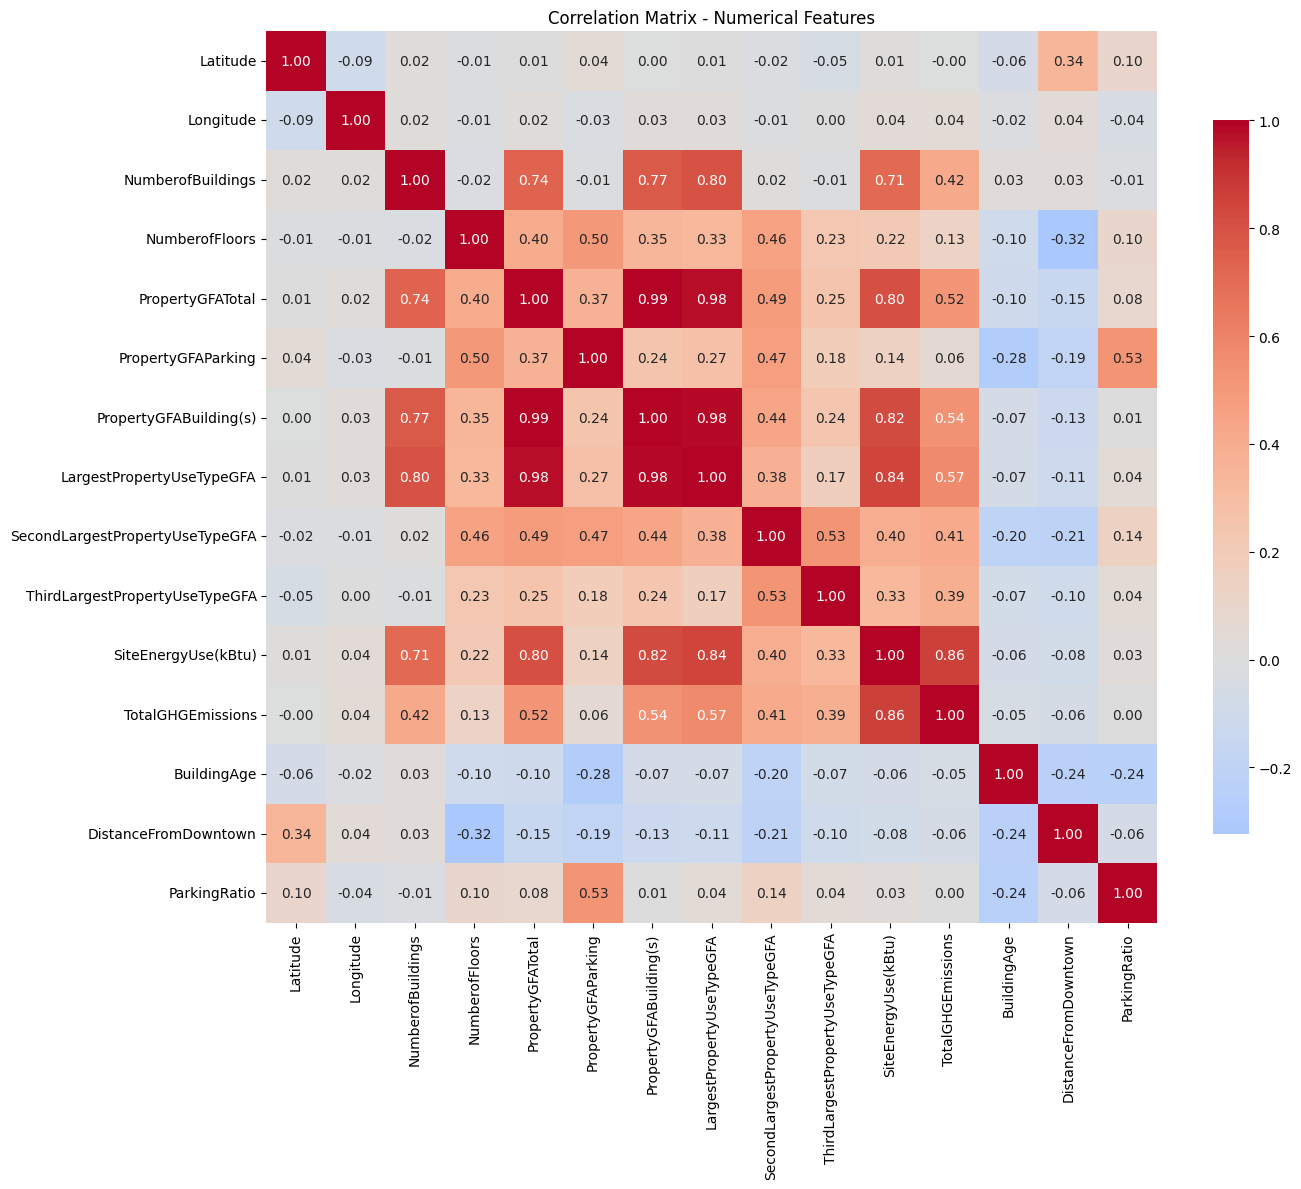


Highly correlated pairs (|correlation| >= 0.8):
PropertyGFATotal <-> PropertyGFABuilding(s): 0.990
PropertyGFATotal <-> LargestPropertyUseTypeGFA: 0.978
PropertyGFATotal <-> SiteEnergyUse(kBtu): 0.804
PropertyGFABuilding(s) <-> LargestPropertyUseTypeGFA: 0.982
PropertyGFABuilding(s) <-> SiteEnergyUse(kBtu): 0.820
LargestPropertyUseTypeGFA <-> SiteEnergyUse(kBtu): 0.842
SiteEnergyUse(kBtu) <-> TotalGHGEmissions: 0.860


In [27]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
threshold = 0.8
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            high_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f"\nHighly correlated pairs (|correlation| >= {threshold}):")
for col1, col2, corr in high_corr:
    print(f"{col1} <-> {col2}: {corr:.3f}")

*Assumption:*
PropertyGFATotal = PropertyGFABuilding(s) + PropertyGFAParking 

And the total is highly correladet with the buildings so let's drop the total and keep the parking and the building ones

In [28]:
# Check if the relationship holds
df['calculated_total'] = df['PropertyGFABuilding(s)'] + df['PropertyGFAParking']
print((df['PropertyGFATotal'] == df['calculated_total']).sum(), "out of", len(df), "rows match exactly")

1628 out of 1628 rows match exactly


In [29]:
df = df.drop(columns=['calculated_total', 'PropertyGFATotal']) 

## Viz to see feature-target relationships

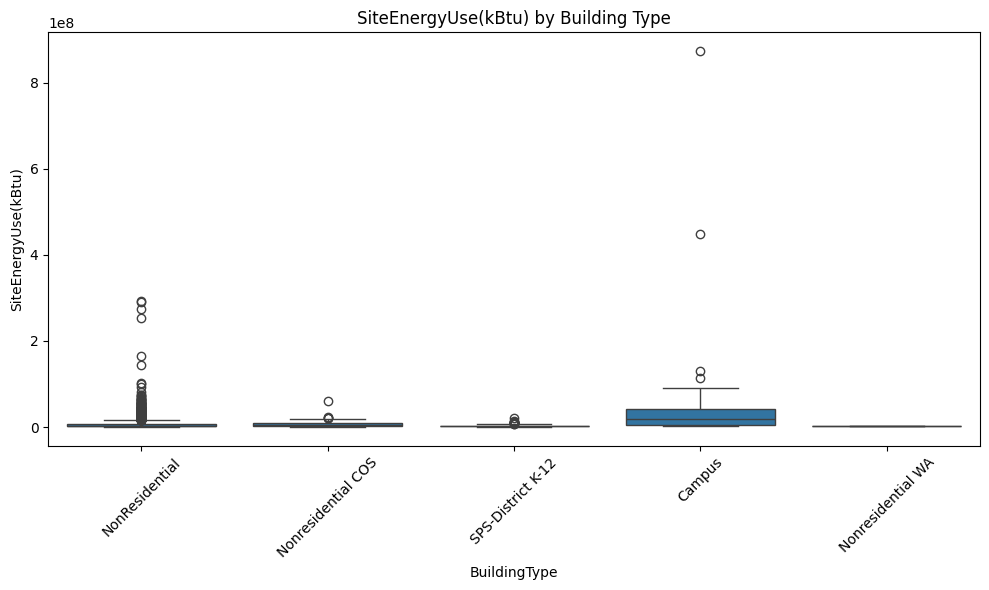

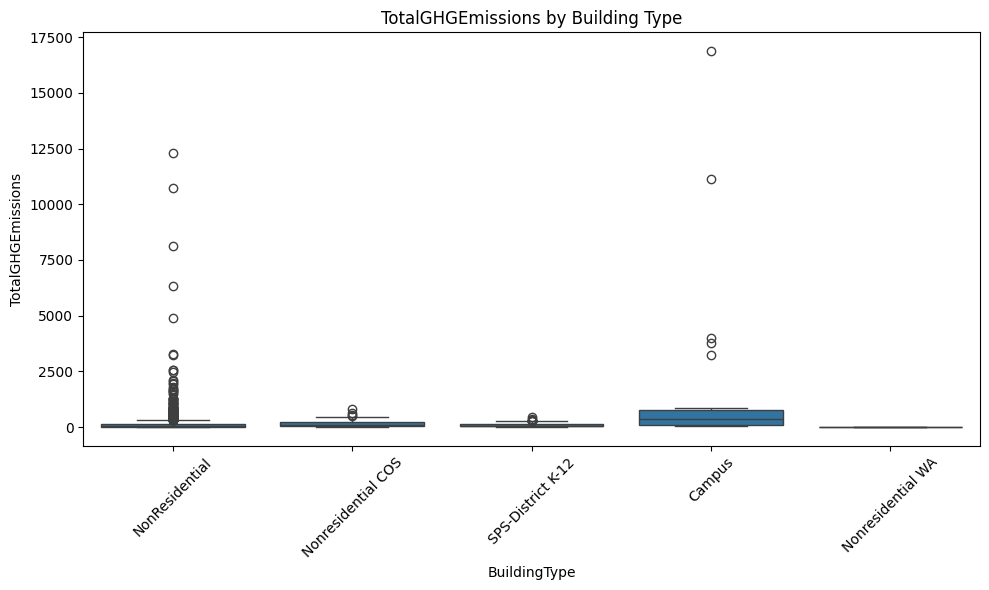

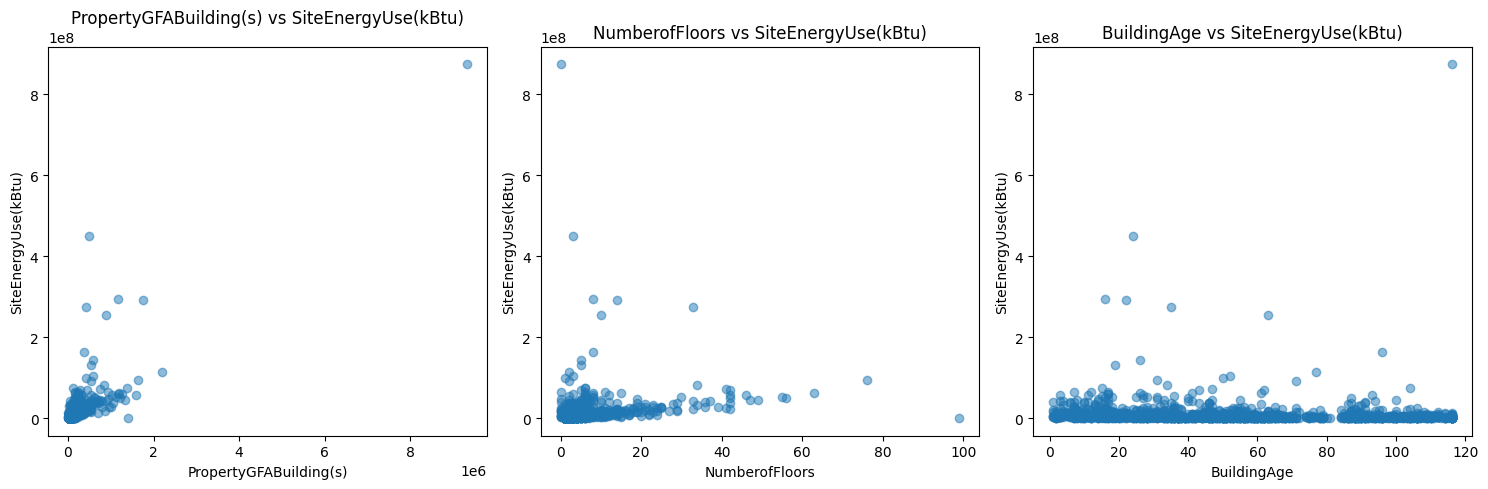

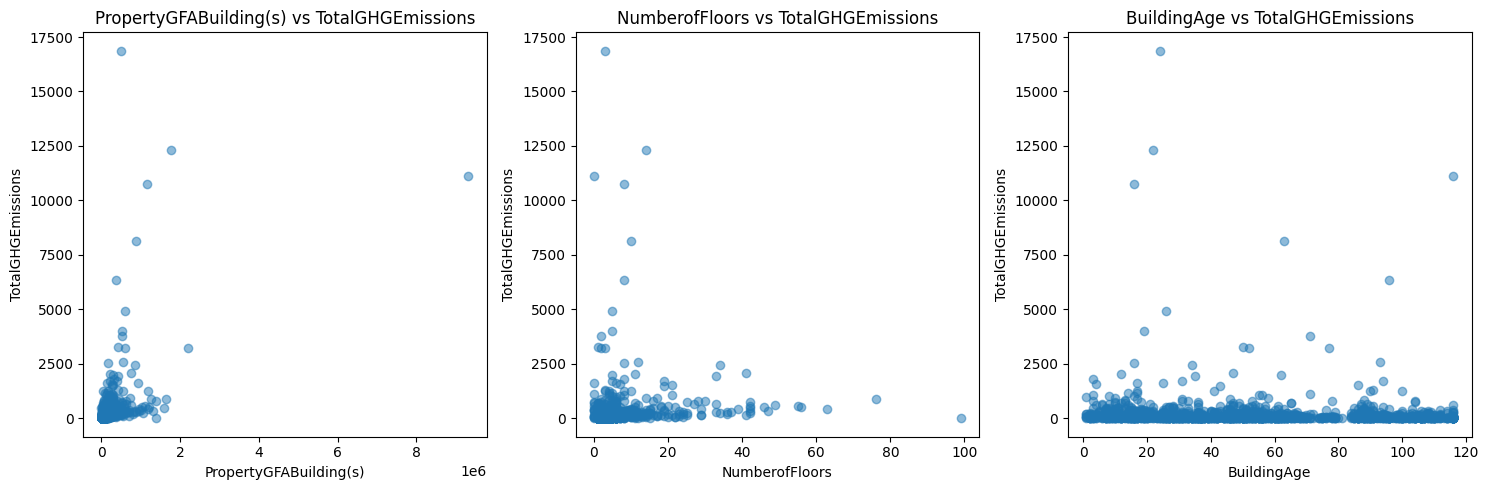

In [30]:
# Boxplots for categorical features
for target in TARGETS:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='BuildingType', y=target)
    plt.xticks(rotation=45)
    plt.title(f'{target} by Building Type')
    plt.tight_layout()
    plt.show()

# Scatterplots for numerical features
numerical_features = ['PropertyGFABuilding(s)', 'NumberofFloors', 'BuildingAge']

for target in TARGETS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, feature in enumerate(numerical_features):
        axes[i].scatter(df[feature], df[target], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target)
        axes[i].set_title(f'{feature} vs {target}')
    plt.tight_layout()
    plt.show()

looks like GFA is a strong predictor. 

NumberofFloors os a weak predictor.

BuildingAge is not a predictor

## One-hot encoding

What to do with categorical values with a lot of distinct values? 40+

In [31]:
for col in ['LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']:
    print(f"\n{col}:")
    display(df[col].value_counts(dropna=False))

# How often is LargestPropertyUseType the same as PrimaryPropertyType?
match = (df['LargestPropertyUseType'] == df['PrimaryPropertyType']).sum()
total = len(df)
print(f"LargestPropertyUseType matches PrimaryPropertyType: {match}/{total} ({match/total:.1%})")


LargestPropertyUseType:


LargestPropertyUseType
Office                                                  487
Non-Refrigerated Warehouse                              199
K-12 School                                             137
Retail Store                                             97
Other                                                    95
Hotel                                                    75
Worship Facility                                         69
Distribution Center                                      54
Medical Office                                           41
Supermarket/Grocery Store                                41
Parking                                                  30
Self-Storage Facility                                    27
College/University                                       24
Residence Hall/Dormitory                                 22
Other - Entertainment/Public Assembly                    21
Other - Recreation                                       21
Senior Care Commu


SecondLargestPropertyUseType:


SecondLargestPropertyUseType
None                                                    787
Parking                                                 333
Office                                                  167
Retail Store                                             85
Other                                                    44
Restaurant                                               29
Non-Refrigerated Warehouse                               29
Data Center                                              12
Multifamily Housing                                      12
Other - Services                                         11
Supermarket/Grocery Store                                10
Fitness Center/Health Club/Gym                            9
Laboratory                                                8
Medical Office                                            8
Other - Entertainment/Public Assembly                     7
Distribution Center                                       7
Bank Branch


ThirdLargestPropertyUseType:


ThirdLargestPropertyUseType
None                                                    1284
Retail Store                                              48
Office                                                    47
Parking                                                   45
Other                                                     39
Restaurant                                                32
Non-Refrigerated Warehouse                                15
Data Center                                               13
Multifamily Housing                                       12
Swimming Pool                                              9
Medical Office                                             9
Food Service                                               8
Social/Meeting Hall                                        8
Other - Restaurant/Bar                                     5
Bank Branch                                                5
Other - Entertainment/Public Assembly                    

LargestPropertyUseType matches PrimaryPropertyType: 624/1628 (38.3%)


##### GFA-weghted encoding

of largest property types

In [32]:
# Get all unique property types across the three columns
all_types = set(df['LargestPropertyUseType'].unique()) | \
            set(df['SecondLargestPropertyUseType'].unique()) | \
            set(df['ThirdLargestPropertyUseType'].unique())
all_types.discard('None')  # Remove 'None'

# Create GFA columns for each property type
for prop_type in all_types:
    df[f'{prop_type}'] = 0.0
    
    # Fill with GFA values from each of the three columns
    mask1 = df['LargestPropertyUseType'] == prop_type
    df.loc[mask1, f'{prop_type}'] += df.loc[mask1, 'LargestPropertyUseTypeGFA']
    
    mask2 = df['SecondLargestPropertyUseType'] == prop_type
    df.loc[mask2, f'{prop_type}'] += df.loc[mask2, 'SecondLargestPropertyUseTypeGFA']
    
    mask3 = df['ThirdLargestPropertyUseType'] == prop_type
    df.loc[mask3, f'{prop_type}'] += df.loc[mask3, 'ThirdLargestPropertyUseTypeGFA']

# Drop the original columns
df = df.drop(columns=[
    'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA'
])

In [33]:
"""#ThirdLargestPropertyUseType is mostly none, so we can drop it
df = df.drop(columns=['ThirdLargestPropertyUseType'])

# One-hot encode Largest one since it's well distributed
df = pd.get_dummies(df, columns=['LargestPropertyUseType'], prefix='Largest')

# One=hot encode the secondlargest but
#first put a threshoold for categories with 10 or more rows
threshold = 10
value_counts = df['SecondLargestPropertyUseType'].value_counts()
top_categories = value_counts[value_counts >= threshold].index.tolist()

# Group rare categories into "Rare" (instead of "Other")
df['SecondLargestPropertyUseType'] = df['SecondLargestPropertyUseType'].apply(
    lambda x: x if x in top_categories else 'Rare'
)

# One-hot encode with prefix for clarity
df = pd.get_dummies(
    df,
    columns=['SecondLargestPropertyUseType'],
    prefix='SecondLargest'
)"""

'#ThirdLargestPropertyUseType is mostly none, so we can drop it\ndf = df.drop(columns=[\'ThirdLargestPropertyUseType\'])\n\n# One-hot encode Largest one since it\'s well distributed\ndf = pd.get_dummies(df, columns=[\'LargestPropertyUseType\'], prefix=\'Largest\')\n\n# One=hot encode the secondlargest but\n#first put a threshoold for categories with 10 or more rows\nthreshold = 10\nvalue_counts = df[\'SecondLargestPropertyUseType\'].value_counts()\ntop_categories = value_counts[value_counts >= threshold].index.tolist()\n\n# Group rare categories into "Rare" (instead of "Other")\ndf[\'SecondLargestPropertyUseType\'] = df[\'SecondLargestPropertyUseType\'].apply(\n    lambda x: x if x in top_categories else \'Rare\'\n)\n\n# One-hot encode with prefix for clarity\ndf = pd.get_dummies(\n    df,\n    columns=[\'SecondLargestPropertyUseType\'],\n    prefix=\'SecondLargest\'\n)'

In [34]:
#one-hot encode the categorical variables with a small
#number of distinct values
df = pd.get_dummies(df, columns=[
    'BuildingType',
    'CouncilDistrictCode',
    'Neighborhood',
    'PrimaryPropertyType'
], prefix=[
    'build',
    'council',
    'hood',
    'primary'
])

In [35]:
#let's check the result
title('Overview')
display(df)        # first and last 5 rows - get a feel for the data

title('Statistics')
display(df.describe())    # stats for numeric columns (mean, min, max...)

title('Info')
df.info()                 # column types + non-null counts

title('Nulls per column')
nulls = df.isnull().sum()
display(nulls[nulls > 0])              # null count per column


title('Duplicate Rows')
display(df.duplicated().sum())          # number of duplicate rows


title('Distinct Values per Column')
display(df.nunique())                   # distinct values per column

### Overview

,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),SiteEnergyUse(kBtu),TotalGHGEmissions,BuildingAge,DistanceFromDowntown,ParkingRatio,Other - Lodging/Residential,Hotel,"Repair Services (Vehicle, Shoe, Locksmith, etc)",Restaurant,Manufacturing/Industrial Plant,K-12 School,Supermarket/Grocery Store,Police Station,Fitness Center/Health Club/Gym,Adult Education,Other - Utility,Convention Center,Lifestyle Center,Financial Office,Enclosed Mall,Courthouse,Residence Hall/Dormitory,Pre-school/Daycare,Worship Facility,Museum,Self-Storage Facility,Wholesale Club/Supercenter,Library,Other - Restaurant/Bar,Convenience Store without Gas Station,Urgent Care/Clinic/Other Outpatient,Other,Hospital (General Medical & Surgical),Senior Care Community,Other - Public Services,Retail Store,Other - Mall,Other - Education,College/University,Multifamily Housing,Data Center,Other - Technology/Science,Bank Branch,Social/Meeting Hall,Bar/Nightclub,Other/Specialty Hospital,Vocational School,Residential Care Facility,Other - Services,Fast Food Restaurant,"Personal Services (Health/Beauty, Dry Cleaning, etc)",Performing Arts,Food Service,Refrigerated Warehouse,Automobile Dealership,Office,Laboratory,Parking,Swimming Pool,Strip Mall,Non-Refrigerated Warehouse,Distribution Center,Movie Theater,Medical Office,Other - Entertainment/Public Assembly,Other - Recreation,Food Sales,Fire Station,build_Campus,build_NonResidential,build_Nonresidential COS,build_Nonresidential WA,build_SPS-District K-12,council_1,council_2,council_3,council_4,council_5,council_6,council_7,hood_BALLARD,hood_Ballard,hood_CENTRAL,hood_Central,hood_DELRIDGE,hood_DOWNTOWN,hood_Delridge,hood_EAST,hood_GREATER DUWAMISH,hood_LAKE UNION,hood_MAGNOLIA / QUEEN ANNE,hood_NORTH,hood_NORTHEAST,hood_NORTHWEST,hood_North,hood_Northwest,hood_SOUTHEAST,hood_SOUTHWEST,primary_Distribution Center,primary_Hospital,primary_Hotel,primary_K-12 School,primary_Laboratory,primary_Large Office,primary_Low-Rise Multifamily,primary_Medical Office,primary_Mixed Use Property,primary_Other,primary_Refrigerated Warehouse,primary_Residence Hall,primary_Restaurant,primary_Retail Store,primary_Self-Storage Facility,primary_Senior Care Community,primary_Small- and Mid-Sized Office,primary_Supermarket / Grocery Store,primary_University,primary_Warehouse,primary_Worship Facility
0,47.61220,-122.33799,1,12,0,88434,7226362.50,249.98,89,0.008408,0.000000,0.0,88434.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,47.61317,-122.33393,1,11,15064,88502,8387933.00,295.86,20,0.007206,0.170211,0.0,83880.0,0.0,4622.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15064.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,47.61393,-122.33810,1,41,196718,759392,72587024.00,2089.28,47,0.009785,0.259047,0.0,756493.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False,Fals

### Statistics

,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),SiteEnergyUse(kBtu),TotalGHGEmissions,BuildingAge,DistanceFromDowntown,ParkingRatio,Other - Lodging/Residential,Hotel,"Repair Services (Vehicle, Shoe, Locksmith, etc)",Restaurant,Manufacturing/Industrial Plant,K-12 School,Supermarket/Grocery Store,Police Station,Fitness Center/Health Club/Gym,Adult Education,Other - Utility,Convention Center,Lifestyle Center,Financial Office,Enclosed Mall,Courthouse,Residence Hall/Dormitory,Pre-school/Daycare,Worship Facility,Museum,Self-Storage Facility,Wholesale Club/Supercenter,Library,Other - Restaurant/Bar,Convenience Store without Gas Station,Urgent Care/Clinic/Other Outpatient,Other,Hospital (General Medical & Surgical),Senior Care Community,Other - Public Services,Retail Store,Other - Mall,Other - Education,College/University,Multifamily Housing,Data Center,Other - Technology/Science,Bank Branch,Social/Meeting Hall,Bar/Nightclub,Other/Specialty Hospital,Vocational School,Residential Care Facility,Other - Services,Fast Food Restaurant,"Personal Services (Health/Beauty, Dry Cleaning, etc)",Performing Arts,Food Service,Refrigerated Warehouse,Automobile Dealership,Office,Laboratory,Parking,Swimming Pool,Strip Mall,Non-Refrigerated Warehouse,Distribution Center,Movie Theater,Medical Office,Other - Entertainment/Public Assembly,Other - Recreation,Food Sales,Fire Station
count,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1.628000e+03,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1628.000000,1628.000000,1628.000000,1628.000000,1628.00000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1628.000000,1628.000000,1628.0,1628.000000,1628.000000,1628.000000,1628.000000,1628.000000,1.628000e+03,1628.000000,1628.000000,1628.000000
mean,47.616115,-122.332911,1.169533,4.166462,13172.855651,1.076048e+05,8.559162e+06,188.135012,53.885135,0.043905,0.115774,106.096437,6633.993243,164.286855,564.047297,212.251843,6682.000614,1319.332310,54.563882,221.280713,76.851351,112.847052,6.584767e+02,245.928133,366.830467,17.649877,378.075553,991.50860,61.622850,1405.727887,114.896192,809.086609,88.928747,250.625921,72.347666,5.963083,182.986486,5617.584152,4.263061e+03,1449.754300,64.810197,5200.738637,403.606265,100.763514,8.971020e+03,981.352580,363.176290,9.546069,105.527641,184.934275,12.233415,142.881450,23.462531,15.698403,264.178133,0.657248,27.515356,95.679975,47.274570,478.350737,221.612408,3.915656e+04,1433.036241,14902.806386,0.0,319.140663,7415.799140,1988.999386,110.466216,2919.292321,2.674609e+03,838.672604,8.554054,23.918305
std,0.048188,0.024462,2.963744,6.631206,42737.189556,2.874348e+05,3.056095e+07,760.305856,32.577849,0.033026,0.394695,1924.253329,45959.713519,2504.292260,3997.372345,3967.367866,28583.529411,8717.776025,2201.569814,3090.256825,1748.366977,3530.047844,2.656853e+04,8157.828655,8336.684766,712.145751,13452.487216,11285.66111,1504.609945,7336.458724,2262.548714,7079.226434,3588.139945,9064.486620,1160.428534,172.376348,4414.517730,31127.768459,6.601048e+04,21633.028292,1726.578099,27923.637430,14001.843752,1728.121025,2.365307e+05,13013.998966,6415.941833,277.469009,1257.125339,2167.475782,306.232303,2604.559673,741.339927,633.406729,3597.407950,26.518965,689.782891,1808.557496,790.928474,7915.485460,3783.030125,1.207777e+05,19368.781275,51305.937072,0.0,6009.435393,31567.894621,13410.769401,2521.571633,23601.669992,5.024296e+04,14715.014973,244.703391,965.067285
m

### Info

...

Series([], dtype: int64)

### Duplicate Rows

np.int64(0)

### Distinct Values per Column

Latitude                               1464
Longitude                              1376
NumberofBuildings                        16
NumberofFloors                           45
PropertyGFAParking                      325
                                       ... 
primary_Small- and Mid-Sized Office       2
primary_Supermarket / Grocery Store       2
primary_University                        2
primary_Warehouse                         2
primary_Worship Facility                  2
Length: 125, dtype: int64

## Visual outlier detection of target variables

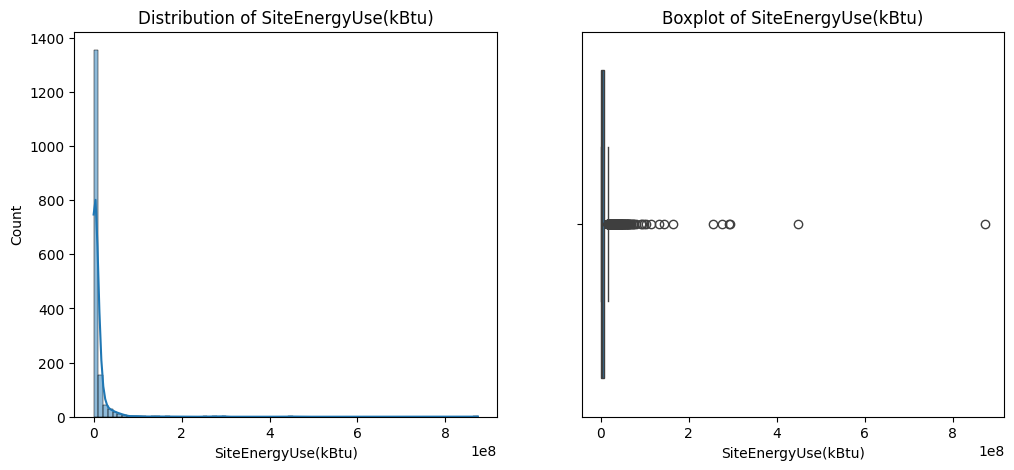

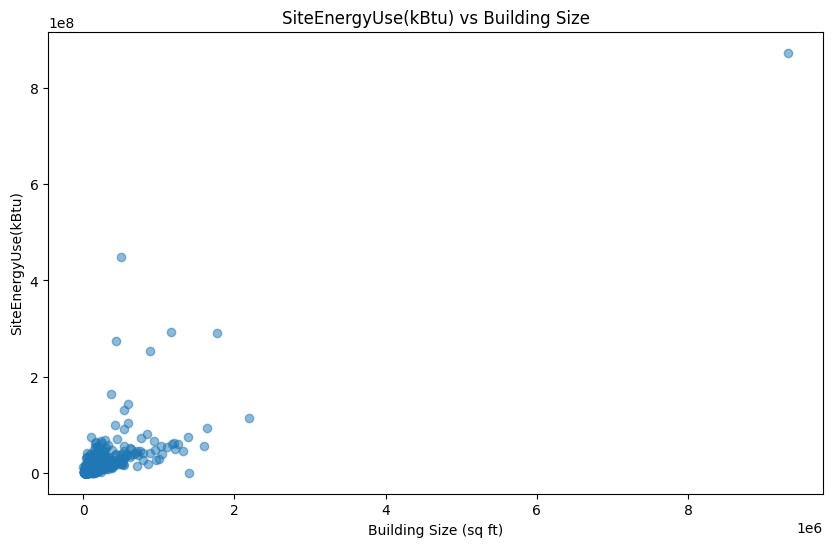

<Figure size 640x480 with 0 Axes>


SiteEnergyUse(kBtu) percentiles:
count    1.628000e+03
mean     8.559162e+06
std      3.056095e+07
min      0.000000e+00
90%      1.731563e+07
95%      3.066975e+07
99%      7.371382e+07
99.9%    3.510156e+08
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64


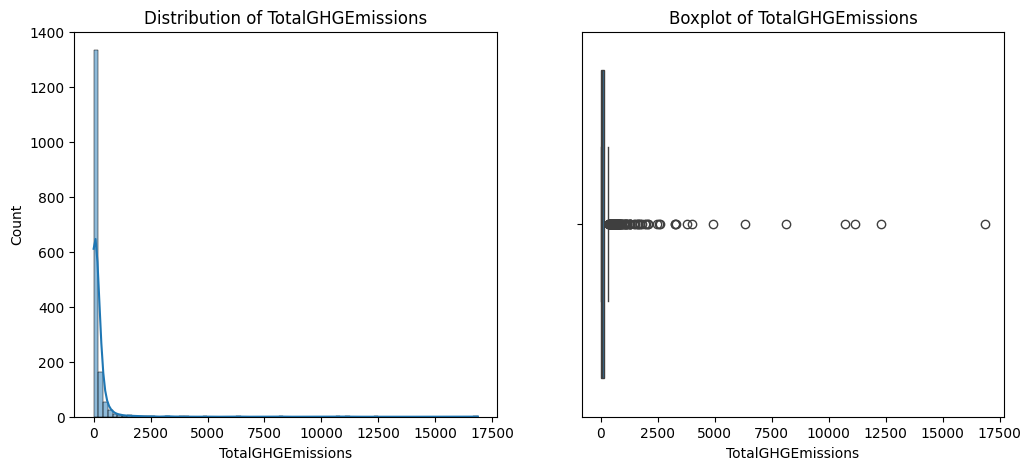

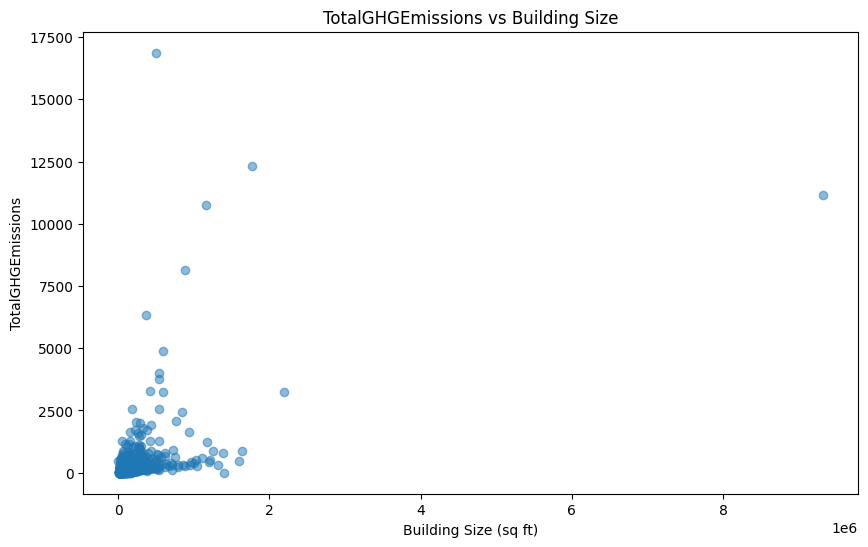

<Figure size 640x480 with 0 Axes>


TotalGHGEmissions percentiles:
count     1628.000000
mean       188.135012
std        760.305856
min          0.000000
90%        348.475000
95%        586.162500
99%       2038.183600
99.9%    11575.701800
max      16870.980000
Name: TotalGHGEmissions, dtype: float64


In [36]:
# Plot distributions for each target
for target in TARGETS:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[target], kde=True)
    plt.title(f'Distribution of {target}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[target])
    plt.title(f'Boxplot of {target}')

    plt.figure(figsize=(10, 6))
    plt.scatter(df['PropertyGFABuilding(s)'], df[target], alpha=0.5)
    plt.xlabel('Building Size (sq ft)')
    plt.ylabel(f'{target}')
    plt.title(f'{target} vs Building Size')
    plt.show()

    plt.tight_layout()
    plt.show()

    #inspect percentiles to understand outliers
    print(f"\n{target} percentiles:")
    print(df[target].describe(percentiles=[.90, .95, .99, .999]))

## Energy use

In [37]:
# Save the full dataset before removing outliers
df_out = df.copy()

# Get the top 1% highest energy consumers
top_1pct = df.nlargest(int(len(df) * 0.01), 'SiteEnergyUse(kBtu)')
# Check their building sizes
#display(top_1pct[['SiteEnergyUse(kBtu)', 'PropertyGFATotal', 'PropertyGFABuilding(s)', 'NumberofFloors', 'BuildingAge']].describe())

#plt.figure(figsize=(10, 6))
#plt.scatter(df['PropertyGFATotal'], df['SiteEnergyUse(kBtu)'], alpha=0.5)
#plt.xlabel('Building Size (sq ft)')
#plt.ylabel('Energy Use (kBtu)')
#plt.title('Energy Use vs Building Size')
#plt.show()


In [38]:
# Compare top 1% vs whole dataset
print("Top 1% energy consumers:")
print(f"  Average building size: {top_1pct['PropertyGFABuilding(s)'].mean():,.0f} sq ft")
print(f"\nWhole dataset:")
print(f"  Average building size: {df['PropertyGFABuilding(s)'].mean():,.0f} sq ft")

#it makes sense, so not an outier

Top 1% energy consumers:
  Average building size: 1,368,116 sq ft

Whole dataset:
  Average building size: 107,605 sq ft


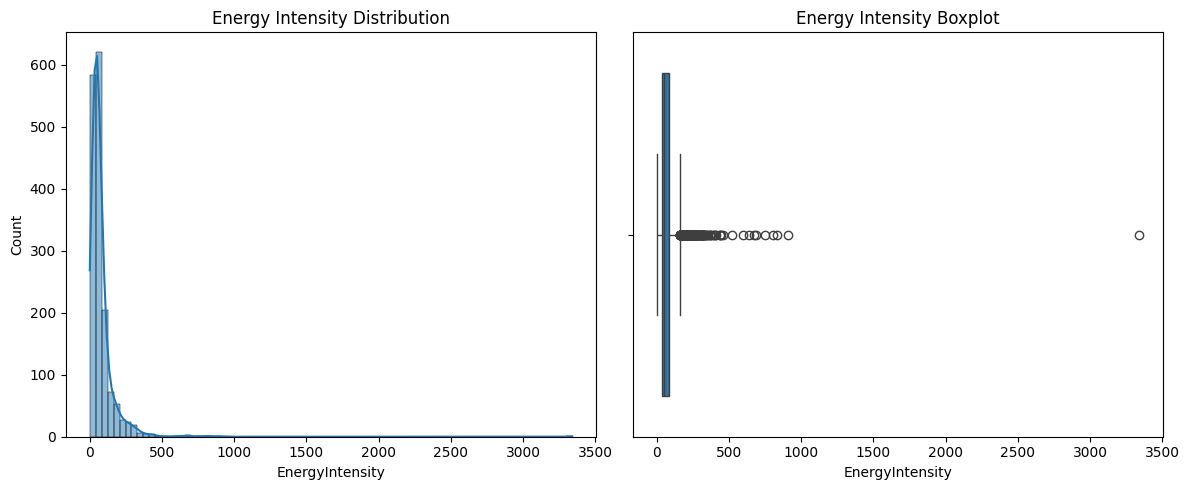

count    1628.000000
mean       76.278391
std       114.430009
min         0.000000
90%       154.950134
95%       218.868981
99%       393.172952
max      3341.232123
Name: EnergyIntensity, dtype: float64


In [39]:
# Calculate energy intensity
df['EnergyIntensity'] = df['SiteEnergyUse(kBtu)'] / df['PropertyGFABuilding(s)']

# Plot both histogram and boxplot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['EnergyIntensity'], kde=True)
plt.title('Energy Intensity Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['EnergyIntensity'])
plt.title('Energy Intensity Boxplot')

plt.tight_layout()
plt.show()

# Check percentiles
print(df['EnergyIntensity'].describe(percentiles=[.90, .95, .99]))

## Let's create an energy intesity variable to find real outliers

In [40]:
# Look at the bottom 1%
bottom_1pct = df.nsmallest(int(len(df) * 0.01), 'SiteEnergyUse(kBtu)')
print(f"Bottom 1% energy range: {bottom_1pct['SiteEnergyUse(kBtu)'].min()} to {bottom_1pct['SiteEnergyUse(kBtu)'].max()}")
display(bottom_1pct[['SiteEnergyUse(kBtu)','TotalGHGEmissions', 'PropertyGFABuilding(s)', 'BuildingAge']])

Bottom 1% energy range: 0.0 to 0.0


,SiteEnergyUse(kBtu),TotalGHGEmissions,PropertyGFABuilding(s),BuildingAge
28,0.0,0.00,126351,61
31,0.0,10.43,51582,27
62,0.0,4.19,53352,68
81,0.0,11.84,74468,17
85,0.0,16.36,58933,25
95,0.0,14.67,66588,25
133,0.0,229.38,160270,57
139,0.0,170.90,136188,53
152,0.0,0.00,52792,27
304,0.0,0.00,1400000,26


In [41]:
#let's remove the top and bottom 1%

# Store the original number of rows
original_rows = len(df)

# Remove the top and bottom outliers in energy intensity
p99_energy = df['EnergyIntensity'].quantile(0.99)
p1_energy = df['EnergyIntensity'].quantile(0.01)
df = df[(df['EnergyIntensity'] >= p1_energy) & (df['EnergyIntensity'] <= p99_energy)]

# Drop the temporary column
df = df.drop(columns='EnergyIntensity')

# Calculate the number of rows deleted
rows_deleted = original_rows - len(df)

print(f"Number of rows deleted: {rows_deleted}")
print(f"Rows after removing energy intensity outliers: {len(df)}")

Number of rows deleted: 34
Rows after removing energy intensity outliers: 1594


## Gas emissions

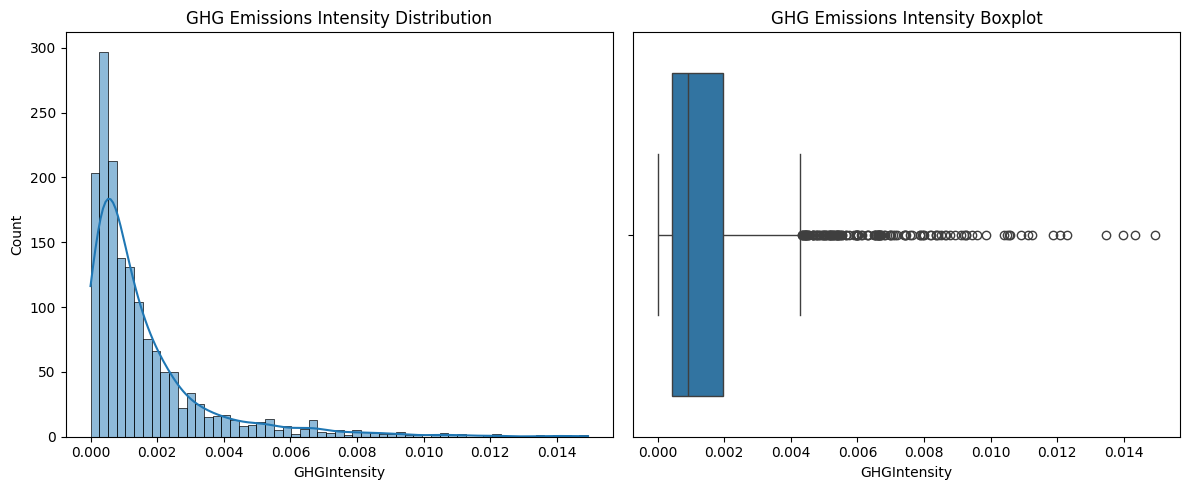

count    1594.000000
mean        0.001608
std         0.001949
min         0.000000
90%         0.003846
95%         0.005654
99%         0.009437
max         0.014935
Name: GHGIntensity, dtype: float64


In [42]:
# Calculate GHG Emissions Intensity
df['GHGIntensity'] = df['TotalGHGEmissions'] / df['PropertyGFABuilding(s)']

# Plot both histogram and boxplot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['GHGIntensity'], kde=True)
plt.title('GHG Emissions Intensity Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['GHGIntensity'])
plt.title('GHG Emissions Intensity Boxplot')

plt.tight_layout()
plt.show()

# Check percentiles
print(df['GHGIntensity'].describe(percentiles=[.90, .95, .99]))

In [43]:
#let's remove the top and bottom %

# Store the original number of rows
original_rows = len(df)

# Remove the top and bottom outliers in energy intensity
p1_ghg = df['GHGIntensity'].quantile(0.01)
p97_ghg = df['GHGIntensity'].quantile(0.97)
df = df[(df['GHGIntensity'] >= p1_ghg) & (df['GHGIntensity'] <= p97_ghg)]

# Drop the temporary column
df = df.drop(columns='GHGIntensity')

# Calculate the number of rows deleted
rows_deleted = original_rows - len(df)

print(f"Number of rows deleted: {rows_deleted}")
print(f"Rows after removing energy intensity outliers: {len(df)}")

Number of rows deleted: 64
Rows after removing energy intensity outliers: 1530


## Let's see the results

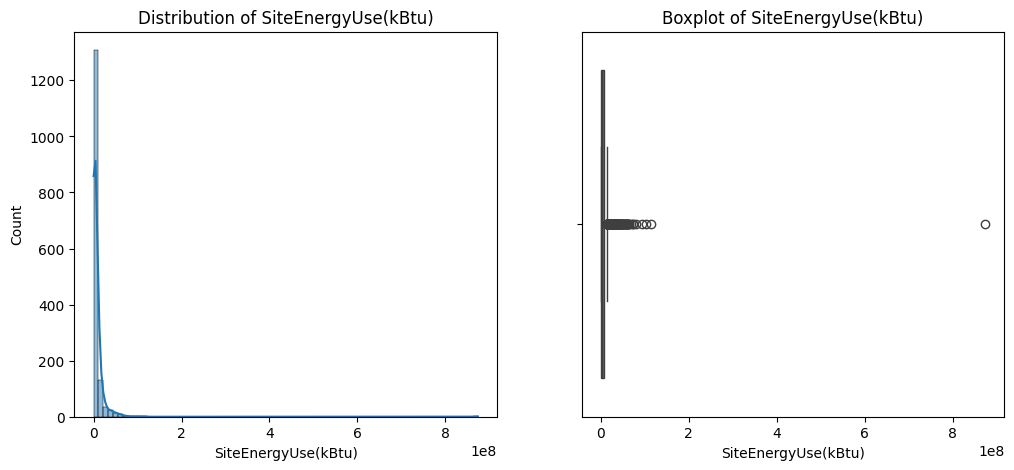

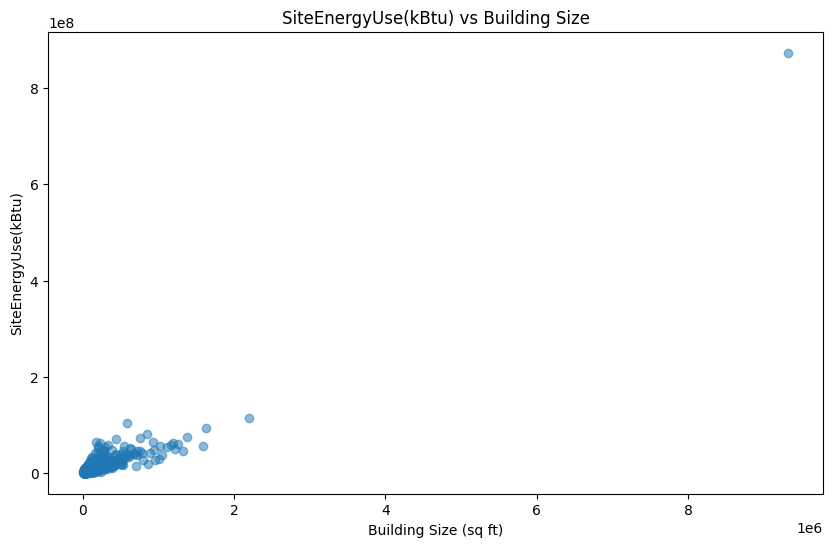

<Figure size 640x480 with 0 Axes>


SiteEnergyUse(kBtu) percentiles:
count    1.530000e+03
mean     6.915213e+06
std      2.464893e+07
min      1.131300e+05
90%      1.588741e+07
95%      2.547504e+07
99%      5.657503e+07
99.9%    1.083138e+08
max      8.739237e+08
Name: SiteEnergyUse(kBtu), dtype: float64


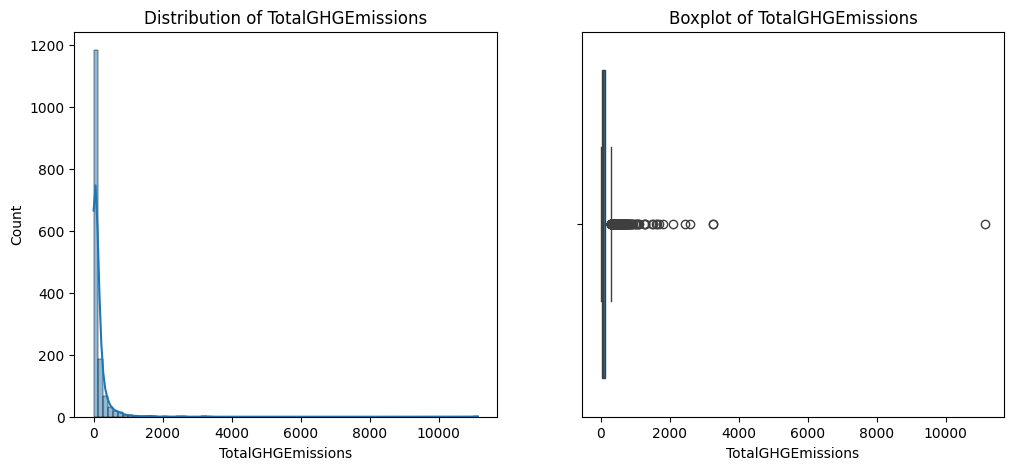

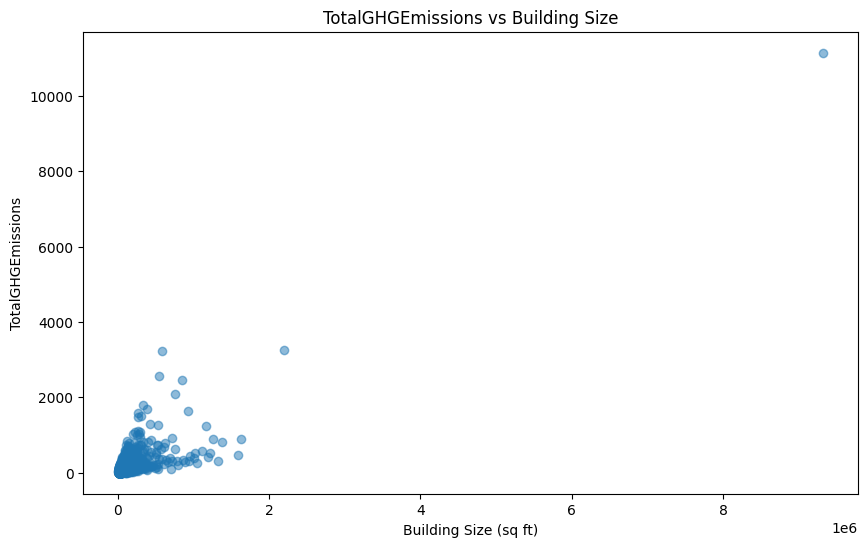

<Figure size 640x480 with 0 Axes>


TotalGHGEmissions percentiles:
count     1530.000000
mean       131.058837
std        370.908777
min          0.820000
90%        294.697000
95%        463.562500
99%       1103.742200
99.9%     3240.708040
max      11140.560000
Name: TotalGHGEmissions, dtype: float64
(1530, 125)


In [44]:
# Plot distributions for each target
for target in TARGETS:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[target], kde=True)
    plt.title(f'Distribution of {target}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[target])
    plt.title(f'Boxplot of {target}')

    plt.figure(figsize=(10, 6))
    plt.scatter(df['PropertyGFABuilding(s)'], df[target], alpha=0.5)
    plt.xlabel('Building Size (sq ft)')
    plt.ylabel(f'{target}')
    plt.title(f'{target} vs Building Size')
    plt.show()

    plt.tight_layout()
    plt.show()

    #inspect percentiles to understand outliers
    print(f"\n{target} percentiles:")
    print(df[target].describe(percentiles=[.90, .95, .99, .999]))

print(df.shape)

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

## Split X and Y to train and test

In [45]:
datasets = {
    'clean': df,
    'with_outliers': df_out
}

splits = {}

from sklearn.model_selection import KFold


# Define the number of folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Store results for all datasets and targets
# Updated results dictionary to hold both Train and Test
results = {}

for dataset_name, data in datasets.items():
    results[dataset_name] = {}
    X = data.drop(columns=TARGETS)

    for target in TARGETS:
        # We now store 'Train' and 'Test' separately
        results[dataset_name][target] = {
            'Train': {'R2': [], 'MAE': [], 'RMSE': []},
            'Test':  {'R2': [], 'MAE': [], 'RMSE': []}
        }
        y = data[target]

        for train_index, test_index in kf.split(X):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            model = LinearRegression()
            model.fit(X_train_scaled, y_train)

            # --- NEW: Training Predictions ---
            y_train_pred = model.predict(X_train_scaled)
            results[dataset_name][target]['Train']['R2'].append(r2_score(y_train, y_train_pred))
            results[dataset_name][target]['Train']['MAE'].append(mean_absolute_error(y_train, y_train_pred))
            results[dataset_name][target]['Train']['RMSE'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))

            # --- Test Predictions (Original) ---
            y_pred = model.predict(X_test_scaled)
            results[dataset_name][target]['Test']['R2'].append(r2_score(y_test, y_pred))
            results[dataset_name][target]['Test']['MAE'].append(mean_absolute_error(y_test, y_pred))
            results[dataset_name][target]['Test']['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))
        # --- Calculate and Print Averages (Simplified) ---
        print(f"--- {dataset_name.upper()} | {target} ---")
        
        # We'll use a simple format for the header
        print(f"{'Stage':<10} | {'R2':<10} | {'MAE':<10} | {'RMSE':<10}")
        print("-" * 45)

        for stage in ['Train', 'Test']:
            # Calculate averages
            r2 = np.mean(results[dataset_name][target][stage]['R2'])
            mae = np.mean(results[dataset_name][target][stage]['MAE'])
            rmse = np.mean(results[dataset_name][target][stage]['RMSE'])
            
            # Formatting: R2 to 3 decimals, others as whole numbers
            print(f"{stage:<10} | {r2:<10.3f} | {int(round(mae)):<10} | {int(round(rmse)):<10}")
        print("\n")
        

--- CLEAN | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.963      | 2087673    | 4070766   
Test       | 0.713      | 2785054    | 7351979   


--- CLEAN | TotalGHGEmissions ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.902      | 62         | 112       
Test       | 0.582      | 79         | 171       


--- WITH_OUTLIERS | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.957      | 2904660    | 6221872   
Test       | 0.688      | 4097791    | 11562280  


--- WITH_OUTLIERS | TotalGHGEmissions ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.924      | 98         | 208       
Test       | 0.453      | 142        | 420       




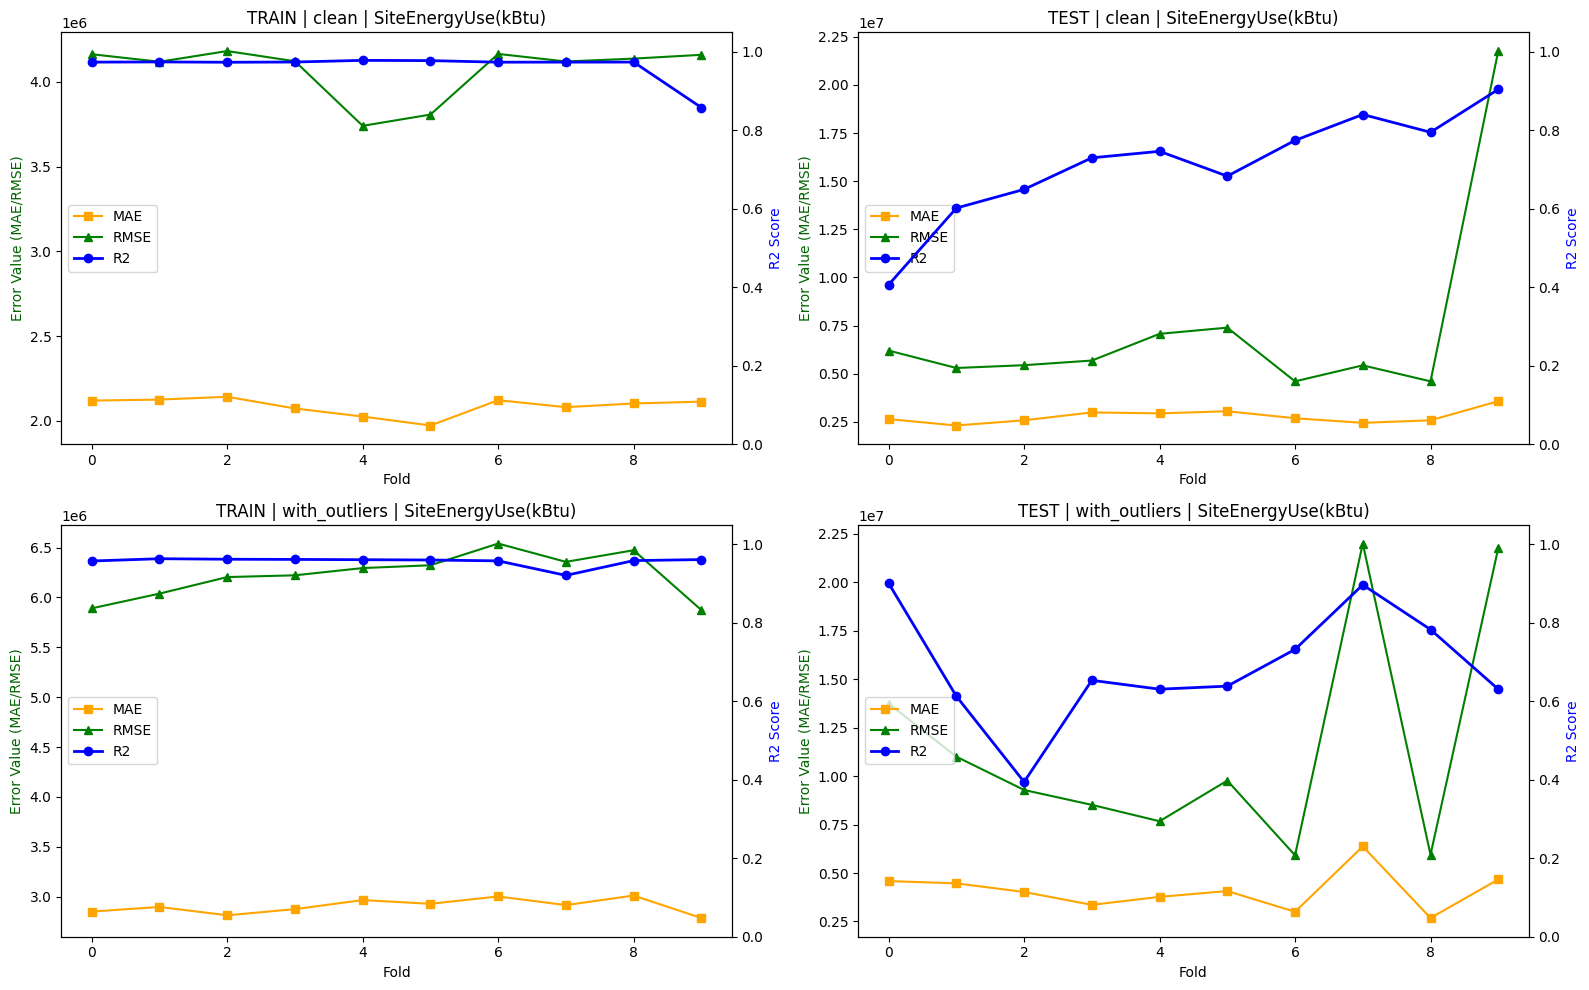

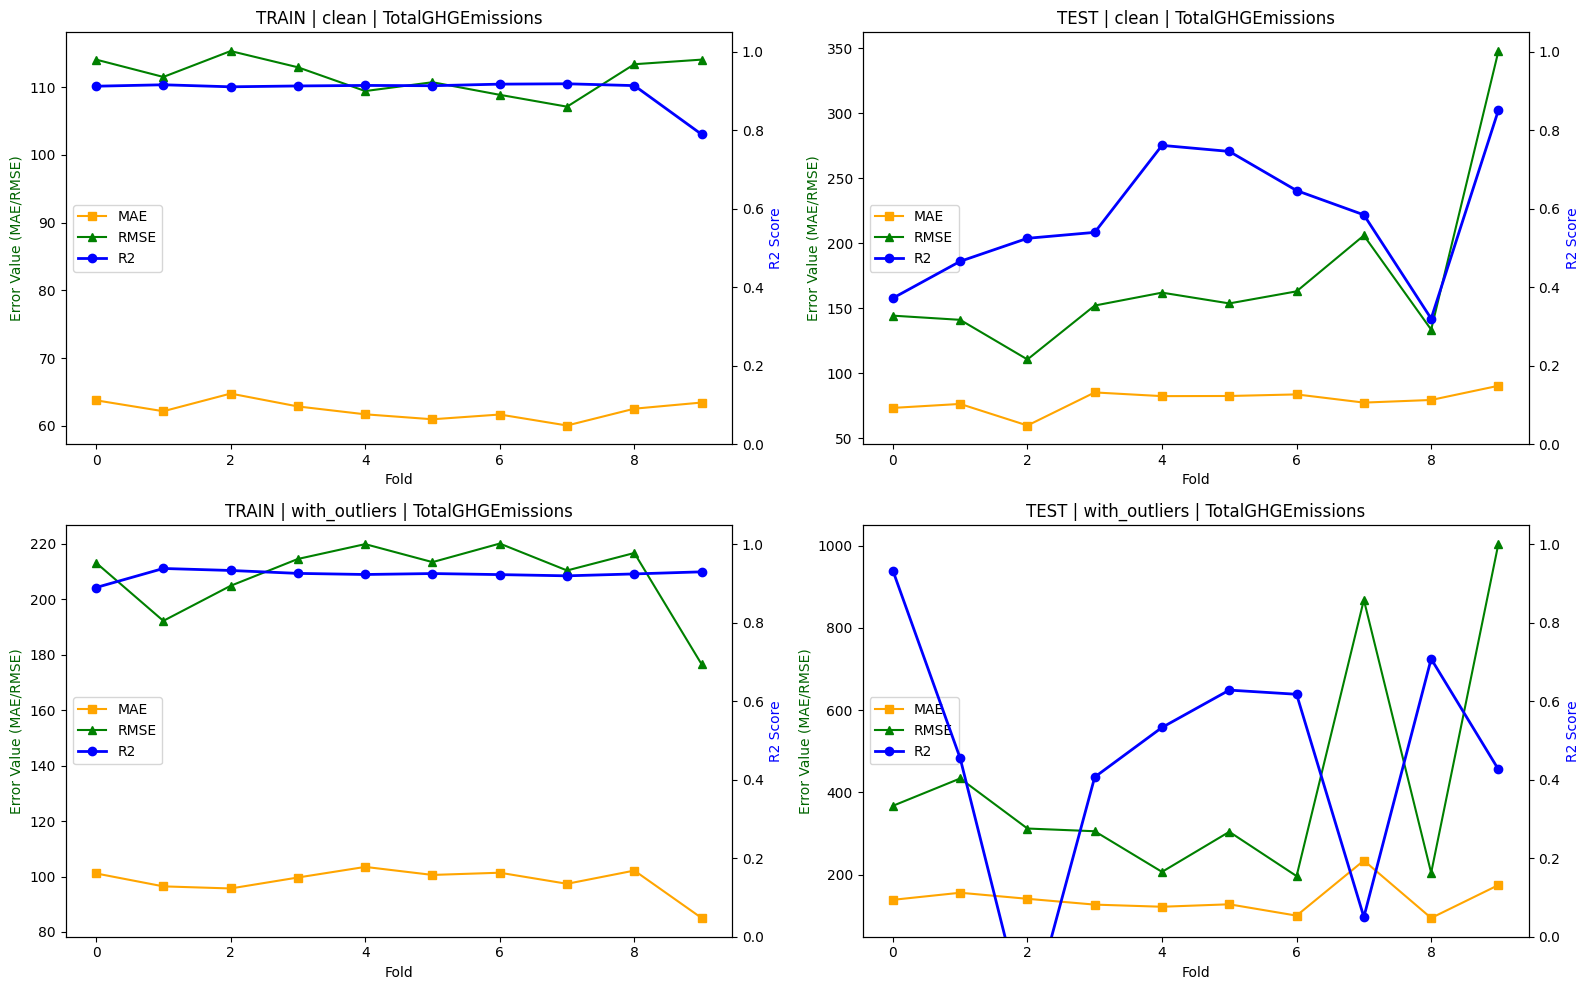

In [46]:
datasets_list = list(results.keys())
targets_list = list(results[datasets_list[0]].keys())

for target in targets_list:
    # One figure per target: 2 rows (datasets) x 2 columns (Train/Test)
    fig, axes = plt.subplots(len(datasets_list), 2, figsize=(16, 10))
    
    for r, d_name in enumerate(datasets_list):
        for c, stage in enumerate(['Train', 'Test']):
            ax1 = axes[r, c]
            data = results[d_name][target][stage]
            
            # --- Left Y-Axis: Error Metrics (MAE & RMSE) ---
            line1, = ax1.plot(data['MAE'], label='MAE', color='orange', marker='s')
            line2, = ax1.plot(data['RMSE'], label='RMSE', color='green', marker='^')
            ax1.set_ylabel('Error Value (MAE/RMSE)', color='darkgreen')
            ax1.set_xlabel('Fold')
            
            # --- Right Y-Axis: R2 Score ---
            ax2 = ax1.twinx()
            line3, = ax2.plot(data['R2'], label='R2', color='blue', marker='o', linewidth=2)
            ax2.set_ylabel('R2 Score', color='blue')
            ax2.set_ylim(0, 1.05) # Keep R2 on a 0-1 scale

            # Combine legends
            lines = [line1, line2, line3]
            labels = [l.get_label() for l in lines]
            ax1.legend(lines, labels, loc='center left')
            
            ax1.set_title(f"{stage.upper()} | {d_name} | {target}")

    plt.tight_layout()
    plt.show()

Test scores are lower then train, so we are overfitting.

## Different models

In [47]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Define the models we want to compare
models = {
    'Linear': {'model': LinearRegression(), 'needs_scaling': True},
    'Ridge': {'model': Ridge(alpha=1.0), 'needs_scaling': True},
    'Lasso': {'model': Lasso(alpha=1.0, max_iter=10000), 'needs_scaling': True},  # Added max_iter
    'ElasticNet': {'model': ElasticNet(alpha=1.0, max_iter=10000), 'needs_scaling': True},
    'RF': {'model': RandomForestRegressor(n_estimators=100, random_state=42), 'needs_scaling': False},
    'XGBoost': {'model': XGBRegressor(n_estimators=100, random_state=42), 'needs_scaling': False},
    'SVR': {'model': SVR(kernel='rbf'), 'needs_scaling': True},
    'Dummy': {'model': DummyRegressor(strategy='mean'), 'needs_scaling': False}
}

results = {}

for dataset_name, data in datasets.items():
    results[dataset_name] = {}
    X = data.drop(columns=TARGETS)

    for target in TARGETS:
        results[dataset_name][target] = {}
        y = data[target]

        for model_name, config in models.items():
            model = config['model']
            results[dataset_name][target][model_name] = {
                'Train': {'R2': [], 'MAE': [], 'RMSE': []},
                'Test':  {'R2': [], 'MAE': [], 'RMSE': []}
            }

            for train_index, test_index in kf.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                # Scale only if needed
                if config['needs_scaling']:
                    scaler = StandardScaler()
                    X_train_scaled = scaler.fit_transform(X_train)
                    X_test_scaled = scaler.transform(X_test)
                else:
                    X_train_scaled = X_train
                    X_test_scaled = X_test

                # Fit and Predict
                model.fit(X_train_scaled, y_train)
                
                # Store Train Metrics
                y_tr_pred = model.predict(X_train_scaled)
                results[dataset_name][target][model_name]['Train']['R2'].append(r2_score(y_train, y_tr_pred))
                results[dataset_name][target][model_name]['Train']['MAE'].append(mean_absolute_error(y_train, y_tr_pred))
                results[dataset_name][target][model_name]['Train']['RMSE'].append(np.sqrt(mean_squared_error(y_train, y_tr_pred)))

                # Store Test Metrics
                y_te_pred = model.predict(X_test_scaled)
                results[dataset_name][target][model_name]['Test']['R2'].append(r2_score(y_test, y_te_pred))
                results[dataset_name][target][model_name]['Test']['MAE'].append(mean_absolute_error(y_test, y_te_pred))
                results[dataset_name][target][model_name]['Test']['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_te_pred)))

            # Print Averages
            print(f"--- {model_name} | {dataset_name} | {target} ---")
            print(f"{'Stage':<10} | {'R2':<10} | {'MAE':<10} | {'RMSE':<10}")
            print("-" * 45)

            for stage in ['Train', 'Test']:
                r2 = np.mean(results[dataset_name][target][model_name][stage]['R2'])
                mae = np.mean(results[dataset_name][target][model_name][stage]['MAE'])
                rmse = np.mean(results[dataset_name][target][model_name][stage]['RMSE'])
                
                # Print with your requested rounding
                print(f"{stage:<10} | {r2:<10.3f} | {int(round(mae)):<10} | {int(round(rmse)):<10}")
            print("\n")

--- Linear | clean | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.963      | 2087673    | 4070766   
Test       | 0.713      | 2785054    | 7351979   


--- Ridge | clean | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.963      | 2082286    | 4074943   
Test       | 0.714      | 2769266    | 7369541   


--- Lasso | clean | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.963      | 2087669    | 4070766   
Test       | 0.713      | 2785082    | 7352047   


--- ElasticNet | clean | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.929      | 2576345    | 6047213   
Test       | 0.729      | 3023469    | 8613643   


--- RF | clean | SiteEnerg

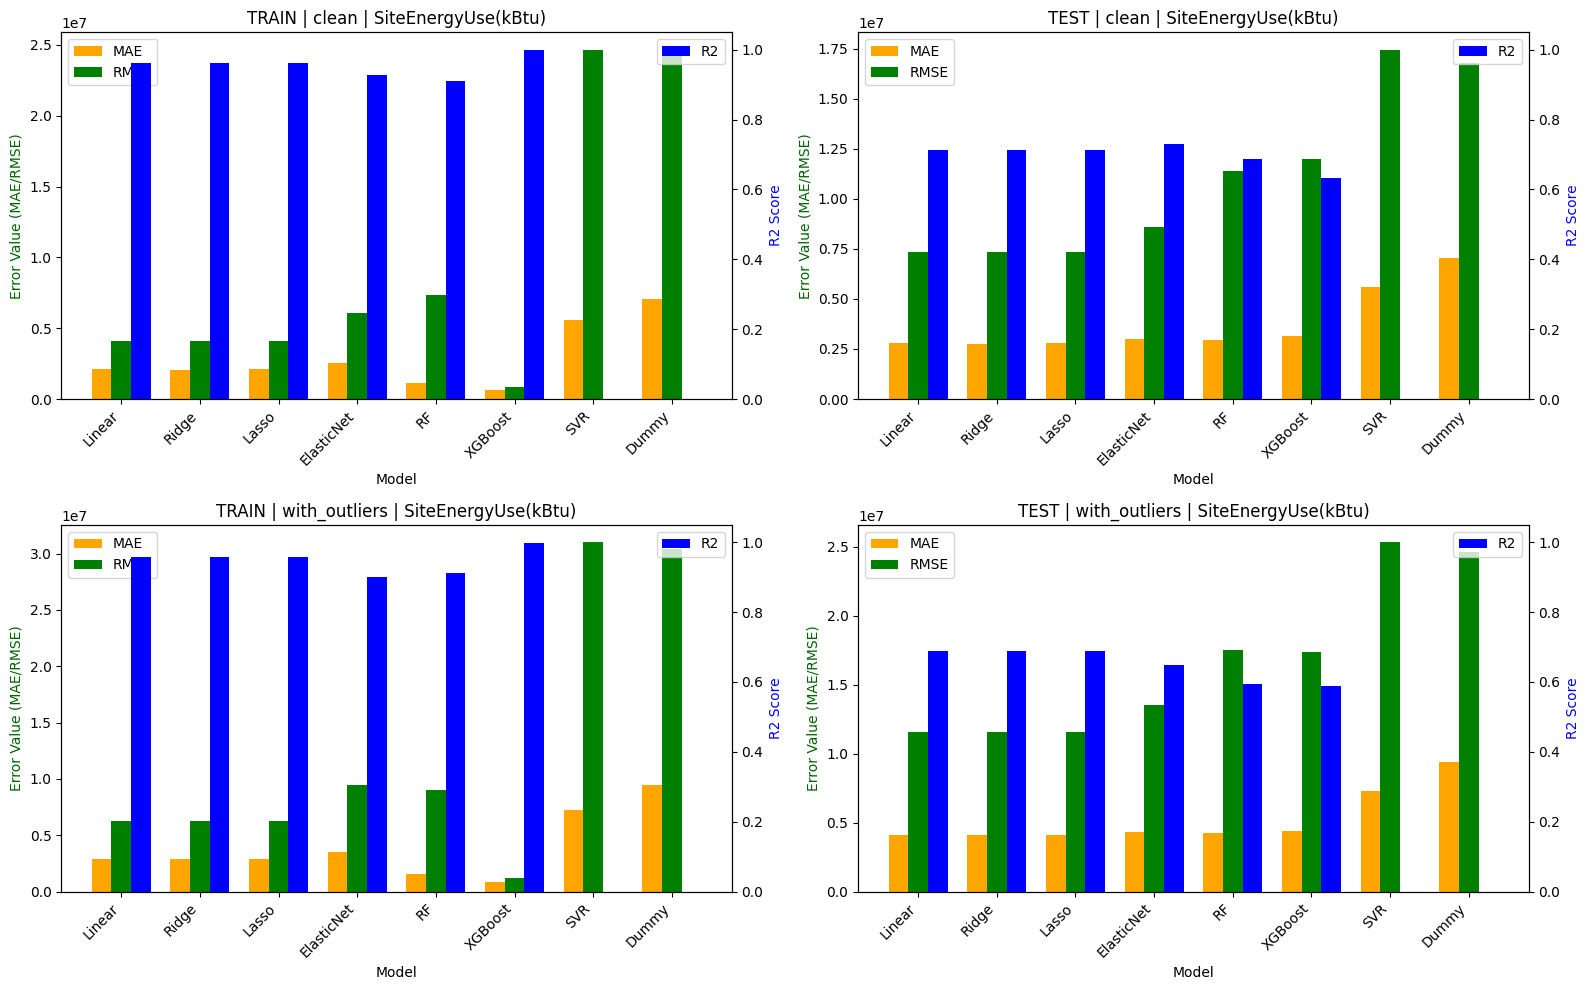

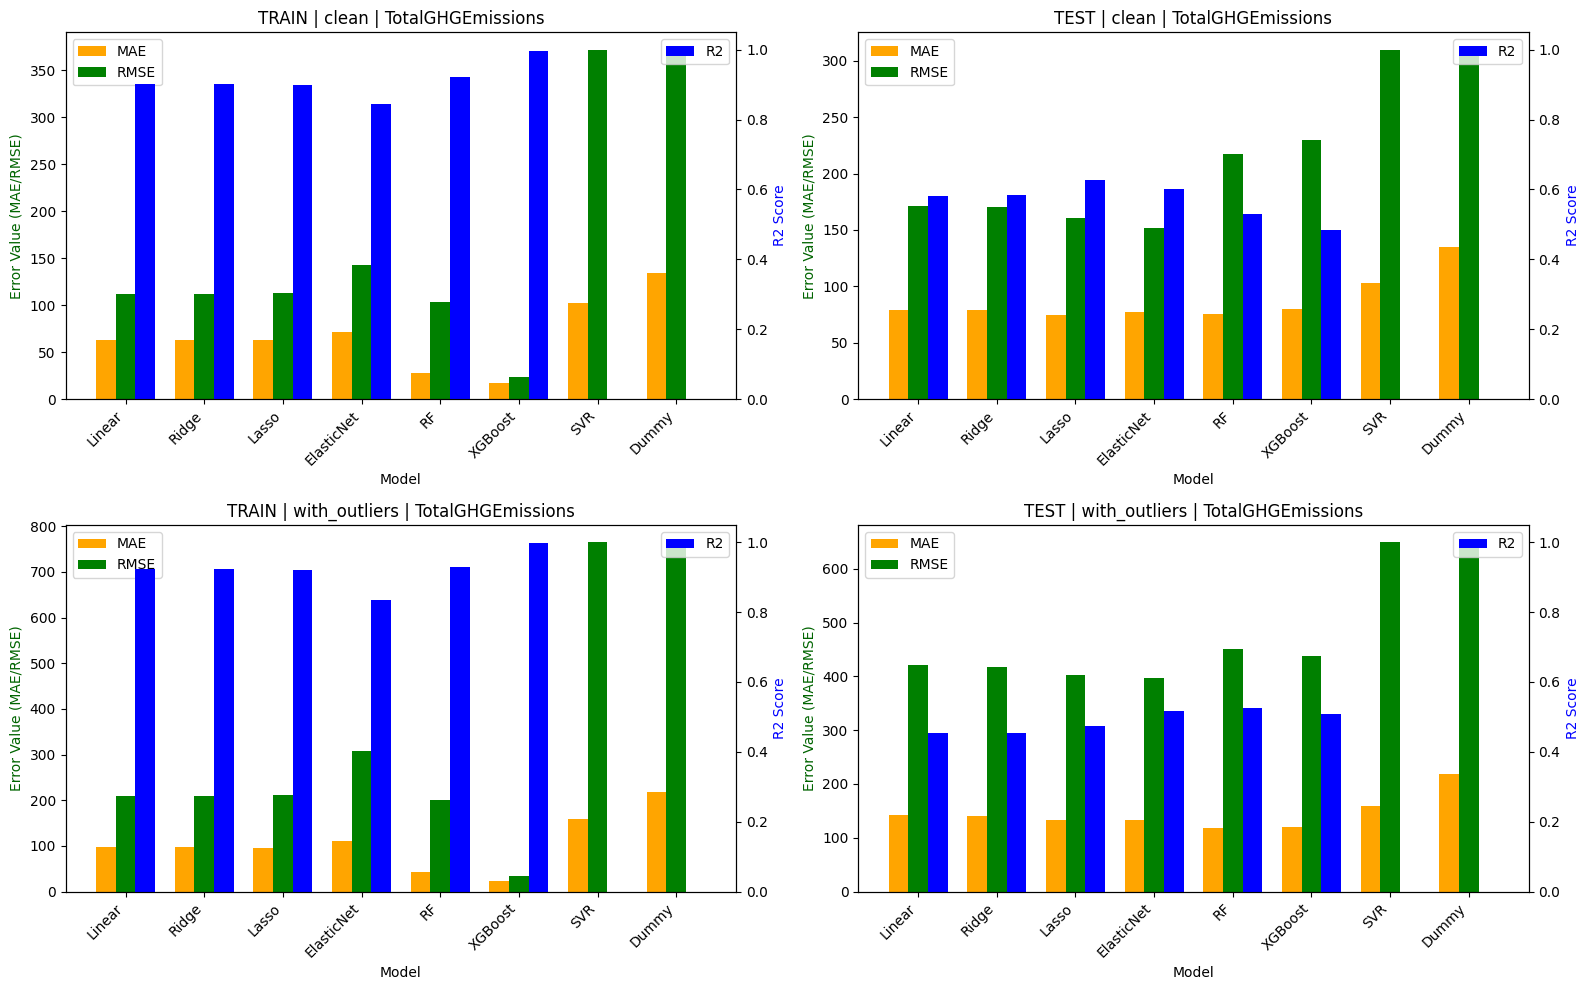

In [48]:
datasets_list = list(results.keys())
targets_list = TARGETS
models_list = list(models.keys())

for target in targets_list:
    # One figure per target: 2 rows (datasets) x 2 columns (Train/Test)
    fig, axes = plt.subplots(len(datasets_list), 2, figsize=(16, 10))
    
    for r, d_name in enumerate(datasets_list):
        for c, stage in enumerate(['Train', 'Test']):
            ax1 = axes[r, c]
            
            # Collect average metrics for all models
            mae_vals = []
            rmse_vals = []
            r2_vals = []
            
            for model_name in models_list:
                mae_vals.append(np.mean(results[d_name][target][model_name][stage]['MAE']))
                rmse_vals.append(np.mean(results[d_name][target][model_name][stage]['RMSE']))
                r2_vals.append(np.mean(results[d_name][target][model_name][stage]['R2']))
            
            x = np.arange(len(models_list))
            width = 0.25
            
            # --- Left Y-Axis: Error Metrics (MAE & RMSE) ---
            bar1 = ax1.bar(x - width, mae_vals, width, label='MAE', color='orange')
            bar2 = ax1.bar(x, rmse_vals, width, label='RMSE', color='green')
            ax1.set_ylabel('Error Value (MAE/RMSE)', color='darkgreen')
            ax1.set_xlabel('Model')
            ax1.set_xticks(x)
            ax1.set_xticklabels(models_list, rotation=45, ha='right')
            
            # --- Right Y-Axis: R2 Score ---
            ax2 = ax1.twinx()
            bar3 = ax2.bar(x + width, r2_vals, width, label='R2', color='blue')
            ax2.set_ylabel('R2 Score', color='blue')
            ax2.set_ylim(0, 1.05)
            
            # Combine legends
            ax1.legend(loc='upper left')
            ax2.legend(loc='upper right')
            
            ax1.set_title(f"{stage.upper()} | {d_name} | {target}")
    
    plt.tight_layout()
    plt.show()

In [49]:
# After all the training loops complete, add this:

print("=" * 60)
print("BEST MODELS SUMMARY")
print("=" * 60)

for dataset_name in results.keys():
    for target in TARGETS:
        print(f"\n{dataset_name.upper()} | {target}")
        print("-" * 60)
        
        # Find best R2 (highest)
        best_r2 = -999
        best_r2_model = None
        
        # Find best MAE (lowest)
        best_mae = float('inf')
        best_mae_model = None
        
        # Find best RMSE (lowest)
        best_rmse = float('inf')
        best_rmse_model = None
        
        for model_name in results[dataset_name][target].keys():
            # Get average test metrics
            r2 = np.mean(results[dataset_name][target][model_name]['Test']['R2'])
            mae = np.mean(results[dataset_name][target][model_name]['Test']['MAE'])
            rmse = np.mean(results[dataset_name][target][model_name]['Test']['RMSE'])
            
            if r2 > best_r2:
                best_r2 = r2
                best_r2_model = model_name
            
            if mae < best_mae:
                best_mae = mae
                best_mae_model = model_name
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_rmse_model = model_name
        
        print(f"Best R²:    {best_r2_model:<12} ({best_r2:.3f})")
        print(f"Best MAE:   {best_mae_model:<12} ({int(round(best_mae))})")
        print(f"Best RMSE:  {best_rmse_model:<12} ({int(round(best_rmse))})")

BEST MODELS SUMMARY

CLEAN | SiteEnergyUse(kBtu)
------------------------------------------------------------
Best R²:    ElasticNet   (0.729)
Best MAE:   Ridge        (2769266)
Best RMSE:  Linear       (7351979)

CLEAN | TotalGHGEmissions
------------------------------------------------------------
Best R²:    Lasso        (0.629)
Best MAE:   Lasso        (75)
Best RMSE:  ElasticNet   (152)

WITH_OUTLIERS | SiteEnergyUse(kBtu)
------------------------------------------------------------
Best R²:    Lasso        (0.688)
Best MAE:   Ridge        (4072751)
Best RMSE:  Lasso        (11562133)

WITH_OUTLIERS | TotalGHGEmissions
------------------------------------------------------------
Best R²:    RF           (0.525)
Best MAE:   RF           (118)
Best RMSE:  ElasticNet   (396)


### Let's see if **energystar** makes it better

In [50]:
# Create temporary copies with ENERGYSTARScore added back
df_temp = df.copy()
df_out_temp = df_out.copy()

# Add ENERGYSTARScore back using index matching
df_temp['ENERGYSTARScore'] = energystar_column.reindex(df_temp.index)
df_out_temp['ENERGYSTARScore'] = energystar_column.reindex(df_out_temp.index)

# Check how many nulls we have
print(f"Nulls in df_temp ENERGYSTARScore: {df_temp['ENERGYSTARScore'].isnull().sum()}")
print(f"Nulls in df_out_temp ENERGYSTARScore: {df_out_temp['ENERGYSTARScore'].isnull().sum()}")

# Fill nulls with median (or you could drop rows, but that changes dataset size)
median_score = energystar_column.median()
df_temp['ENERGYSTARScore'] = df_temp['ENERGYSTARScore'].fillna(median_score)
df_out_temp['ENERGYSTARScore'] = df_out_temp['ENERGYSTARScore'].fillna(median_score)

# Create a new datasets dict for comparison
datasets_with_energystar = {
    'clean_with_energystar': df_temp,
    'with_outliers_with_energystar': df_out_temp
}

# Now run your model training code using datasets_with_energystar instead of datasets
# Keep the original datasets dict unchanged for comparison

Nulls in df_temp ENERGYSTARScore: 492
Nulls in df_out_temp ENERGYSTARScore: 551


In [51]:
# Define the models we want to compare
models = {
    'Linear': {'model': LinearRegression(), 'needs_scaling': True},
    'Ridge': {'model': Ridge(alpha=1.0), 'needs_scaling': True},
    'Lasso': {'model': Lasso(alpha=1.0, max_iter=10000), 'needs_scaling': True},  # Added max_iter
    'ElasticNet': {'model': ElasticNet(alpha=1.0, max_iter=10000), 'needs_scaling': True},
    'RF': {'model': RandomForestRegressor(n_estimators=100, random_state=42), 'needs_scaling': False},
    'XGBoost': {'model': XGBRegressor(n_estimators=100, random_state=42), 'needs_scaling': False},
    'SVR': {'model': SVR(kernel='rbf'), 'needs_scaling': True},
    'Dummy': {'model': DummyRegressor(strategy='mean'), 'needs_scaling': False}
}

results_with_energystar = {}

for dataset_name, data in datasets_with_energystar.items():
    results_with_energystar[dataset_name] = {}
    X = data.drop(columns=TARGETS)

    for target in TARGETS:
        results_with_energystar[dataset_name][target] = {}
        y = data[target]

        for model_name, config in models.items():
            model = config['model']
            results_with_energystar[dataset_name][target][model_name] = {
                'Train': {'R2': [], 'MAE': [], 'RMSE': []},
                'Test':  {'R2': [], 'MAE': [], 'RMSE': []}
            }

            for train_index, test_index in kf.split(X):
                X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                # Scale only if needed
                if config['needs_scaling']:
                    scaler = StandardScaler()
                    X_train_scaled = scaler.fit_transform(X_train)
                    X_test_scaled = scaler.transform(X_test)
                else:
                    X_train_scaled = X_train
                    X_test_scaled = X_test

                # Fit and Predict
                model.fit(X_train_scaled, y_train)
                
                # Store Train Metrics
                y_tr_pred = model.predict(X_train_scaled)
                results_with_energystar[dataset_name][target][model_name]['Train']['R2'].append(r2_score(y_train, y_tr_pred))
                results_with_energystar[dataset_name][target][model_name]['Train']['MAE'].append(mean_absolute_error(y_train, y_tr_pred))
                results_with_energystar[dataset_name][target][model_name]['Train']['RMSE'].append(np.sqrt(mean_squared_error(y_train, y_tr_pred)))

                # Store Test Metrics
                y_te_pred = model.predict(X_test_scaled)
                results_with_energystar[dataset_name][target][model_name]['Test']['R2'].append(r2_score(y_test, y_te_pred))
                results_with_energystar[dataset_name][target][model_name]['Test']['MAE'].append(mean_absolute_error(y_test, y_te_pred))
                results_with_energystar[dataset_name][target][model_name]['Test']['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_te_pred)))

            # Print Averages
            print(f"--- {model_name} | {dataset_name} | {target} ---")
            print(f"{'Stage':<10} | {'R2':<10} | {'MAE':<10} | {'RMSE':<10}")
            print("-" * 45)

            for stage in ['Train', 'Test']:
                r2 = np.mean(results_with_energystar[dataset_name][target][model_name][stage]['R2'])
                mae = np.mean(results_with_energystar[dataset_name][target][model_name][stage]['MAE'])
                rmse = np.mean(results_with_energystar[dataset_name][target][model_name][stage]['RMSE'])
                
                # Print with your requested rounding
                print(f"{stage:<10} | {r2:<10.3f} | {int(round(mae)):<10} | {int(round(rmse)):<10}")
            print("\n")

--- Linear | clean_with_energystar | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.966      | 2009631    | 3916782   
Test       | 0.720      | 2700077    | 7300024   


--- Ridge | clean_with_energystar | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.966      | 2006285    | 3920971   
Test       | 0.721      | 2685565    | 7312888   


--- Lasso | clean_with_energystar | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.966      | 2009627    | 3916782   
Test       | 0.720      | 2700241    | 7300131   


--- ElasticNet | clean_with_energystar | SiteEnergyUse(kBtu) ---
Stage      | R2         | MAE        | RMSE      
---------------------------------------------
Train      | 0.931      | 2463273    | 5955518   
Test       | 0

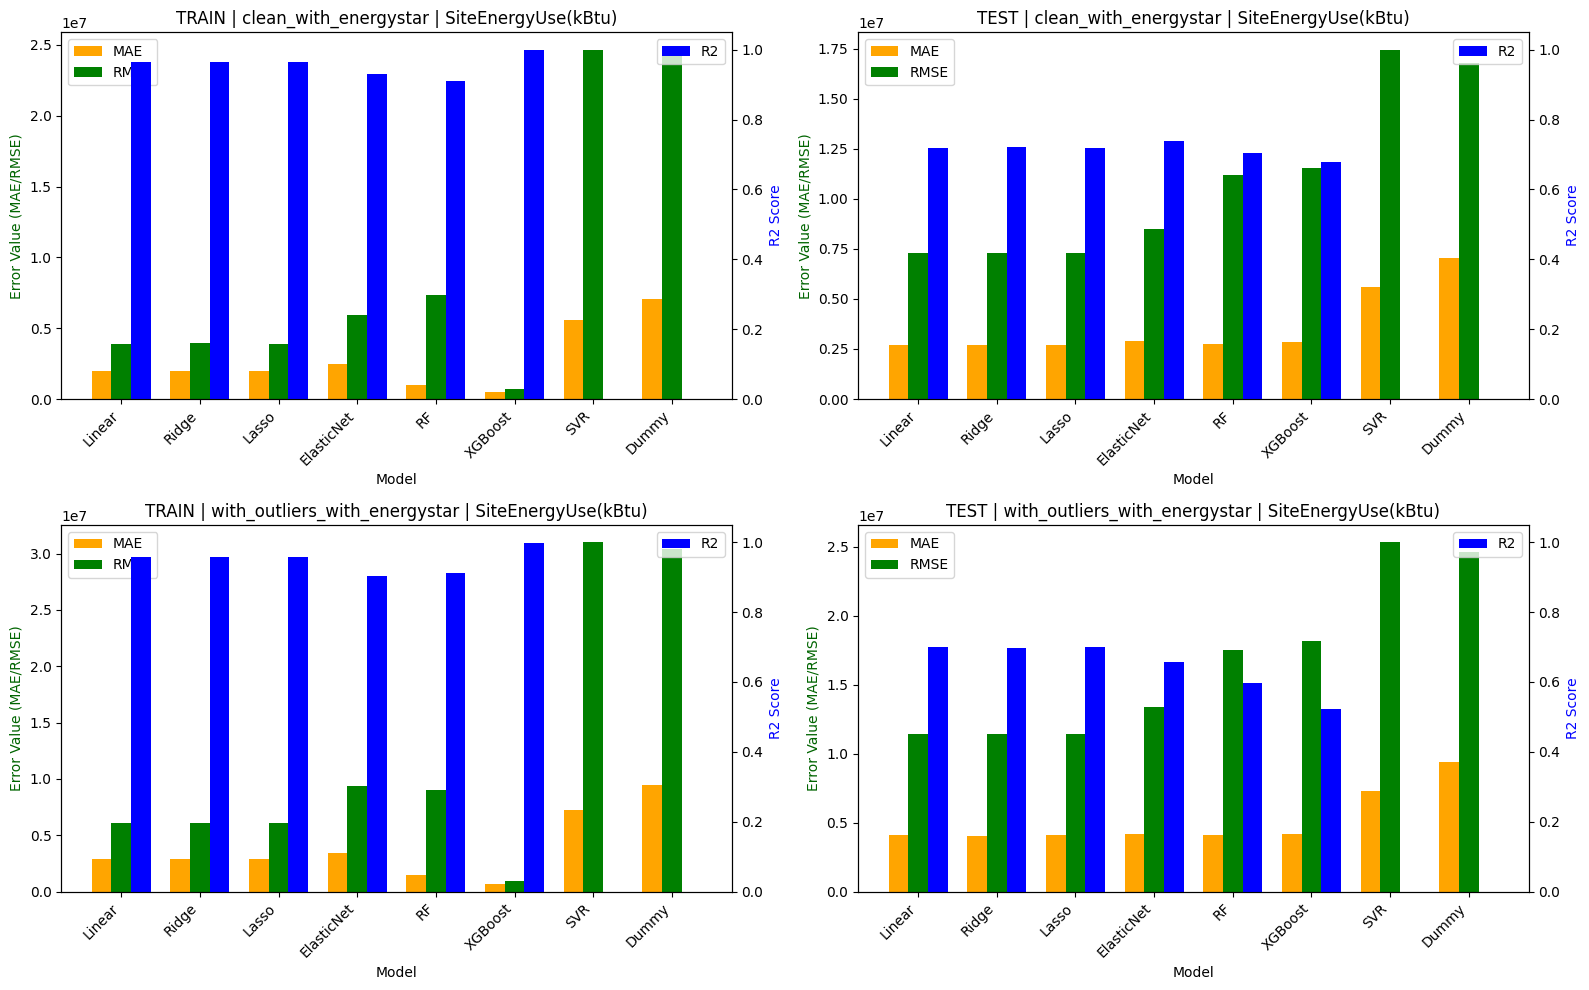

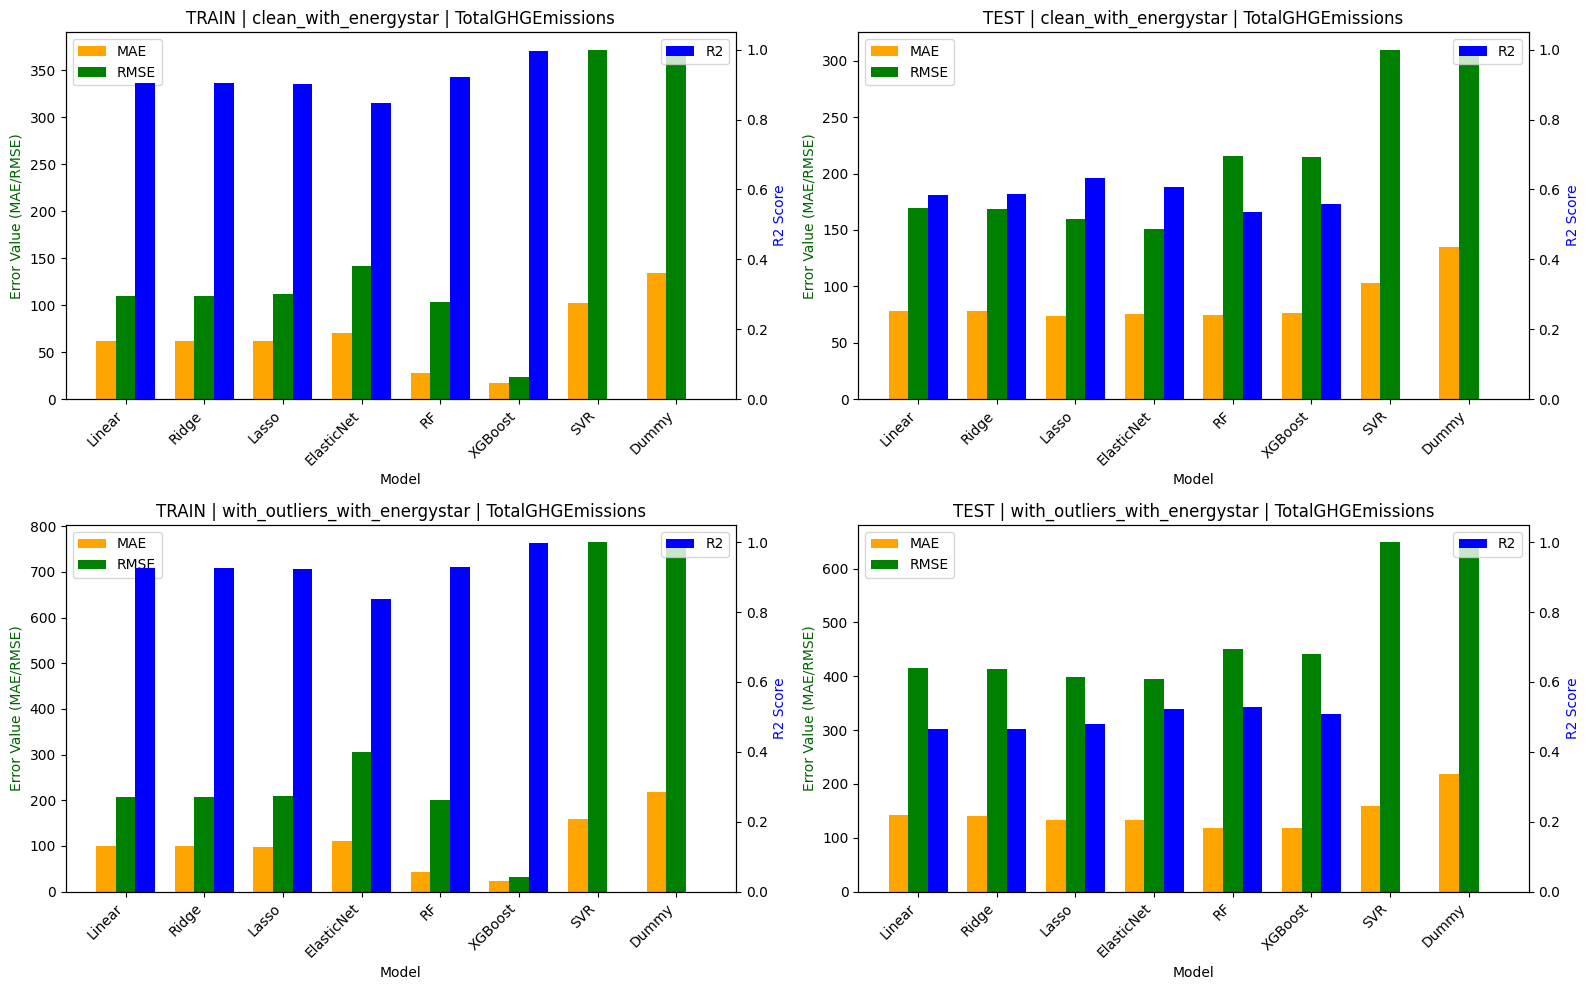

In [52]:
datasets_list = list(results_with_energystar.keys())
targets_list = TARGETS
models_list = list(models.keys())

for target in targets_list:
    # One figure per target: 2 rows (datasets) x 2 columns (Train/Test)
    fig, axes = plt.subplots(len(datasets_list), 2, figsize=(16, 10))
    
    for r, d_name in enumerate(datasets_list):
        for c, stage in enumerate(['Train', 'Test']):
            ax1 = axes[r, c]
            
            # Collect average metrics for all models
            mae_vals = []
            rmse_vals = []
            r2_vals = []
            
            for model_name in models_list:
                mae_vals.append(np.mean(results_with_energystar[d_name][target][model_name][stage]['MAE']))
                rmse_vals.append(np.mean(results_with_energystar[d_name][target][model_name][stage]['RMSE']))
                r2_vals.append(np.mean(results_with_energystar[d_name][target][model_name][stage]['R2']))
            
            x = np.arange(len(models_list))
            width = 0.25
            
            # --- Left Y-Axis: Error Metrics (MAE & RMSE) ---
            bar1 = ax1.bar(x - width, mae_vals, width, label='MAE', color='orange')
            bar2 = ax1.bar(x, rmse_vals, width, label='RMSE', color='green')
            ax1.set_ylabel('Error Value (MAE/RMSE)', color='darkgreen')
            ax1.set_xlabel('Model')
            ax1.set_xticks(x)
            ax1.set_xticklabels(models_list, rotation=45, ha='right')
            
            # --- Right Y-Axis: R2 Score ---
            ax2 = ax1.twinx()
            bar3 = ax2.bar(x + width, r2_vals, width, label='R2', color='blue')
            ax2.set_ylabel('R2 Score', color='blue')
            ax2.set_ylim(0, 1.05)
            
            # Combine legends
            ax1.legend(loc='upper left')
            ax2.legend(loc='upper right')
            
            ax1.set_title(f"{stage.upper()} | {d_name} | {target}")
    
    plt.tight_layout()
    plt.show()

In [53]:
# After all the training loops complete, add this:

print("=" * 60)
print("BEST MODELS SUMMARY")
print("=" * 60)

for dataset_name in results_with_energystar.keys():
    for target in TARGETS:
        print(f"\n{dataset_name.upper()} | {target}")
        print("-" * 60)
        
        # Find best R2 (highest)
        best_r2 = -999
        best_r2_model = None
        
        # Find best MAE (lowest)
        best_mae = float('inf')
        best_mae_model = None
        
        # Find best RMSE (lowest)
        best_rmse = float('inf')
        best_rmse_model = None
        
        for model_name in results_with_energystar[dataset_name][target].keys():
            # Get average test metrics
            r2 = np.mean(results_with_energystar[dataset_name][target][model_name]['Test']['R2'])
            mae = np.mean(results_with_energystar[dataset_name][target][model_name]['Test']['MAE'])
            rmse = np.mean(results_with_energystar[dataset_name][target][model_name]['Test']['RMSE'])
            
            if r2 > best_r2:
                best_r2 = r2
                best_r2_model = model_name
            
            if mae < best_mae:
                best_mae = mae
                best_mae_model = model_name
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_rmse_model = model_name
        
        print(f"Best R²:    {best_r2_model:<12} ({best_r2:.3f})")
        print(f"Best MAE:   {best_mae_model:<12} ({int(round(best_mae))})")
        print(f"Best RMSE:  {best_rmse_model:<12} ({int(round(best_rmse))})")

BEST MODELS SUMMARY

CLEAN_WITH_ENERGYSTAR | SiteEnergyUse(kBtu)
------------------------------------------------------------
Best R²:    ElasticNet   (0.740)
Best MAE:   Ridge        (2685565)
Best RMSE:  Linear       (7300024)

CLEAN_WITH_ENERGYSTAR | TotalGHGEmissions
------------------------------------------------------------
Best R²:    Lasso        (0.632)
Best MAE:   Lasso        (74)
Best RMSE:  ElasticNet   (151)

WITH_OUTLIERS_WITH_ENERGYSTAR | SiteEnergyUse(kBtu)
------------------------------------------------------------
Best R²:    Lasso        (0.699)
Best MAE:   Ridge        (4036715)
Best RMSE:  Lasso        (11391316)

WITH_OUTLIERS_WITH_ENERGYSTAR | TotalGHGEmissions
------------------------------------------------------------
Best R²:    RF           (0.529)
Best MAE:   RF           (117)
Best RMSE:  ElasticNet   (394)


### Let's see how much better the results are with **EnergyStar**?!

In [54]:
# Assuming you've run the training code and have:
# results (without ENERGYSTARScore)
# results_with_energystar (with ENERGYSTARScore)

print("=" * 80)
print("ENERGYSTAR SCORE IMPACT COMPARISON")
print("=" * 80)

comparison_summary = []

for dataset_name in ['clean', 'with_outliers']:
    for target in TARGETS:
        print(f"\n{dataset_name.upper()} | {target}")
        print("-" * 80)
        
        # Find best scores WITHOUT ENERGYSTARScore
        best_r2_without = max([np.mean(results[dataset_name][target][model]['Test']['R2']) 
                                for model in results[dataset_name][target].keys()])
        best_mae_without = min([np.mean(results[dataset_name][target][model]['Test']['MAE']) 
                                 for model in results[dataset_name][target].keys()])
        best_rmse_without = min([np.mean(results[dataset_name][target][model]['Test']['RMSE']) 
                                  for model in results[dataset_name][target].keys()])
        
        # Find corresponding dataset name in results_with_energystar
        dataset_with = f"{dataset_name}_with_energystar"
        
        # Find best scores WITH ENERGYSTARScore
        best_r2_with = max([np.mean(results_with_energystar[dataset_with][target][model]['Test']['R2']) 
                            for model in results_with_energystar[dataset_with][target].keys()])
        best_mae_with = min([np.mean(results_with_energystar[dataset_with][target][model]['Test']['MAE']) 
                             for model in results_with_energystar[dataset_with][target].keys()])
        best_rmse_with = min([np.mean(results_with_energystar[dataset_with][target][model]['Test']['RMSE']) 
                              for model in results_with_energystar[dataset_with][target].keys()])
        
        # Calculate percent improvement
        r2_improvement = ((best_r2_with - best_r2_without) / best_r2_without) * 100
        mae_improvement = ((best_mae_without - best_mae_with) / best_mae_without) * 100
        rmse_improvement = ((best_rmse_without - best_rmse_with) / best_rmse_without) * 100
        
        print(f"{'Metric':<10} | {'Without':<12} | {'With':<12} | {'Improvement':<12}")
        print(f"R²         | {best_r2_without:<12.3f} | {best_r2_with:<12.3f} | {r2_improvement:>+11.2f}%")
        print(f"MAE        | {best_mae_without:<12.0f} | {best_mae_with:<12.0f} | {mae_improvement:>+11.2f}%")
        print(f"RMSE       | {best_rmse_without:<12.0f} | {best_rmse_with:<12.0f} | {rmse_improvement:>+11.2f}%")
        
        comparison_summary.append({
            'dataset': dataset_name,
            'target': target,
            'r2_improvement': r2_improvement,
            'mae_improvement': mae_improvement,
            'rmse_improvement': rmse_improvement
        })

# Overall average improvement
print("\n" + "=" * 80)
print("OVERALL AVERAGE IMPROVEMENT ACROSS ALL DATASETS AND TARGETS")
print("=" * 80)

avg_r2 = np.mean([x['r2_improvement'] for x in comparison_summary])
avg_mae = np.mean([x['mae_improvement'] for x in comparison_summary])
avg_rmse = np.mean([x['rmse_improvement'] for x in comparison_summary])

print(f"R²:    {avg_r2:>+6.2f}%")
print(f"MAE:   {avg_mae:>+6.2f}%")
print(f"RMSE:  {avg_rmse:>+6.2f}%")

ENERGYSTAR SCORE IMPACT COMPARISON

CLEAN | SiteEnergyUse(kBtu)
--------------------------------------------------------------------------------
Metric     | Without      | With         | Improvement 
R²         | 0.729        | 0.740        |       +1.46%
MAE        | 2769266      | 2685565      |       +3.02%
RMSE       | 7351979      | 7300024      |       +0.71%

CLEAN | TotalGHGEmissions
--------------------------------------------------------------------------------
Metric     | Without      | With         | Improvement 
R²         | 0.629        | 0.632        |       +0.54%
MAE        | 75           | 74           |       +1.29%
RMSE       | 152          | 151          |       +0.82%

WITH_OUTLIERS | SiteEnergyUse(kBtu)
--------------------------------------------------------------------------------
Metric     | Without      | With         | Improvement 
R²         | 0.688        | 0.699        |       +1.65%
MAE        | 4072751      | 4036715      |       +0.88%
RMSE       | 

We impute a lot of data for 1-2% gain and it's a performance rating while we need to use only the structural data.

So it's better to omit it.

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

ElasticNet for Energy

Lasso for emissions

ElasticNet Best CV R²: 0.727
ElasticNet Test R²: 0.673


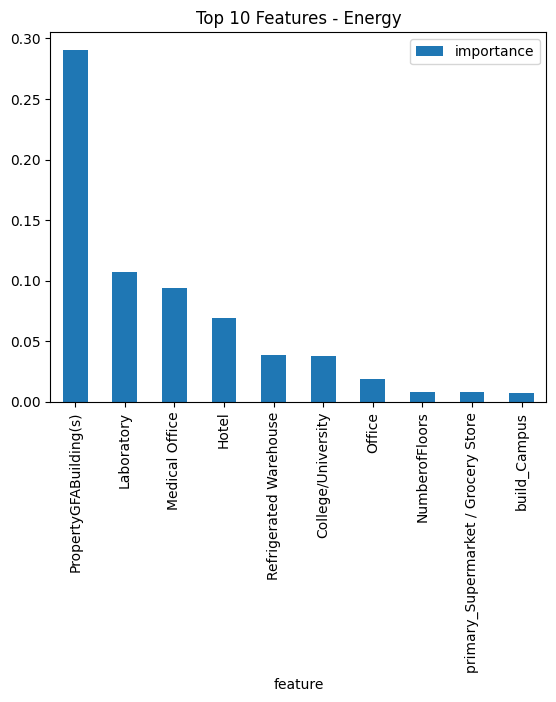

Lasso Best CV R²: 0.575
Lasso Test R²: 0.563


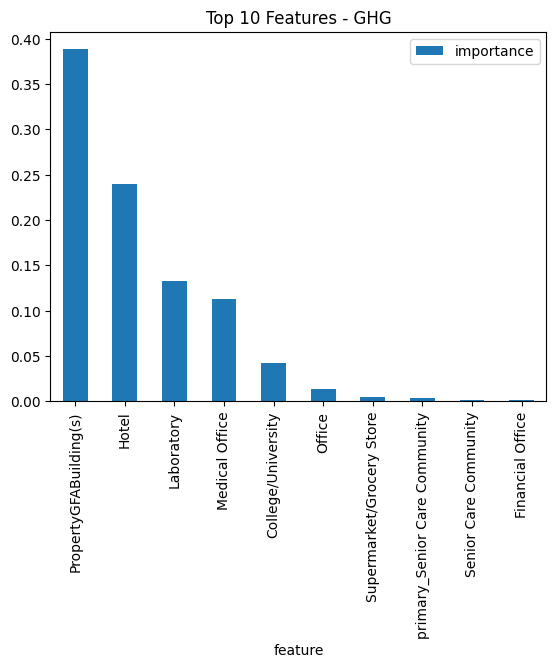

In [59]:
# Load data
X = df.drop(columns=TARGETS)
y_energy = df['SiteEnergyUse(kBtu)']
y_ghg = df['TotalGHGEmissions']

# Split once for both targets
X_train, X_test, y_train_energy, y_test_energy = train_test_split(
    X, y_energy, test_size=0.2, random_state=42
)
y_train_ghg = y_ghg.loc[y_train_energy.index]
y_test_ghg = y_ghg.loc[y_test_energy.index]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ElasticNet for Energy
elastic_params = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # Add more values
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.99],  # Add more values
    'max_iter': [10000]
}
elastic_grid = GridSearchCV(ElasticNet(), elastic_params, cv=10, scoring='r2', n_jobs=-1)
elastic_grid.fit(X_train_scaled, y_train_energy)
print(f"ElasticNet Best CV R²: {elastic_grid.best_score_:.3f}")
print(f"ElasticNet Test R²: {r2_score(y_test_energy, elastic_grid.predict(X_test_scaled)):.3f}")

# Feature importance for Energy
perm_energy = permutation_importance(elastic_grid.best_estimator_, X_test_scaled, y_test_energy, n_repeats=10, random_state=42)
top_features_energy = pd.DataFrame({'feature': X.columns, 'importance': perm_energy.importances_mean}).sort_values('importance', ascending=False)
top_features_energy.head(10).plot.bar(x='feature', y='importance', title='Top 10 Features - Energy')
plt.show()

# Lasso for GHG
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    'max_iter': [10000],
    'selection': ['cyclic', 'random']
}
lasso_grid = GridSearchCV(Lasso(), lasso_params, cv=10, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train_ghg)

y_pred_ghg = lasso_grid.predict(X_test_scaled)
r2_original = r2_score(y_test_ghg, y_pred_ghg)
mae_original = mean_absolute_error(y_test_ghg, y_pred_ghg)
rmse_original = np.sqrt(mean_squared_error(y_test_ghg, y_pred_ghg))

print(f"Lasso Best CV R²: {lasso_grid.best_score_:.3f}")
print(f"Lasso Test R²: {r2_score(y_test_ghg, lasso_grid.predict(X_test_scaled)):.3f}")

# Feature importance for GHG
perm_ghg = permutation_importance(lasso_grid.best_estimator_, X_test_scaled, y_test_ghg, n_repeats=10, random_state=42)
top_features_ghg = pd.DataFrame({'feature': X.columns, 'importance': perm_ghg.importances_mean}).sort_values('importance', ascending=False)
top_features_ghg.head(10).plot.bar(x='feature', y='importance', title='Top 10 Features - GHG')
plt.show()

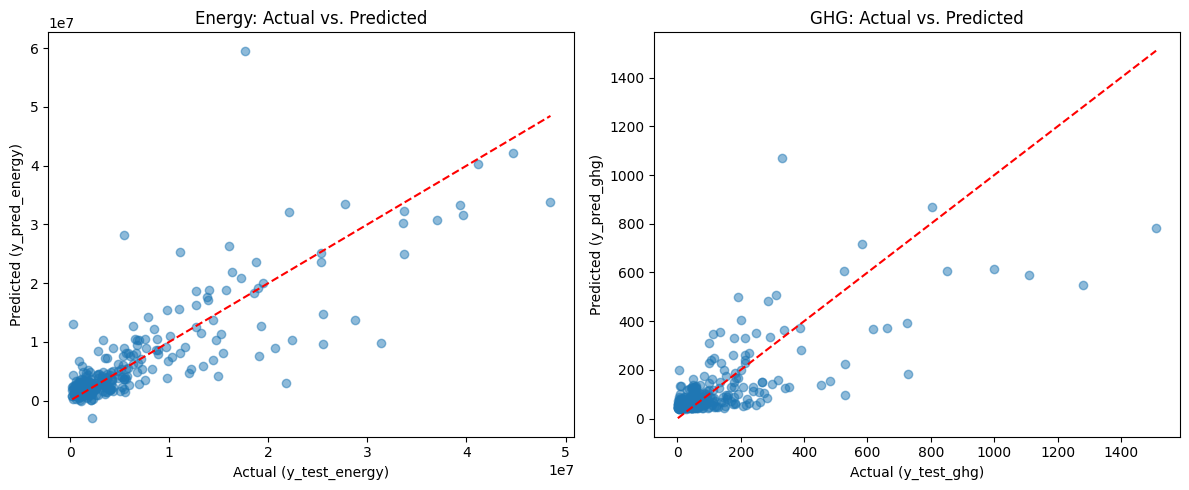

In [60]:
# Predictions
y_pred_energy = elastic_grid.predict(X_test_scaled)
y_pred_ghg = lasso_grid.predict(X_test_scaled)

# Plot for Energy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test_energy, y_pred_energy, alpha=0.5)
plt.plot([y_test_energy.min(), y_test_energy.max()], [y_test_energy.min(), y_test_energy.max()], 'r--')
plt.xlabel('Actual (y_test_energy)')
plt.ylabel('Predicted (y_pred_energy)')
plt.title('Energy: Actual vs. Predicted')

# Plot for GHG
plt.subplot(1, 2, 2)
plt.scatter(y_test_ghg, y_pred_ghg, alpha=0.5)
plt.plot([y_test_ghg.min(), y_test_ghg.max()], [y_test_ghg.min(), y_test_ghg.max()], 'r--')
plt.xlabel('Actual (y_test_ghg)')
plt.ylabel('Predicted (y_pred_ghg)')
plt.title('GHG: Actual vs. Predicted')

plt.tight_layout()
plt.show()

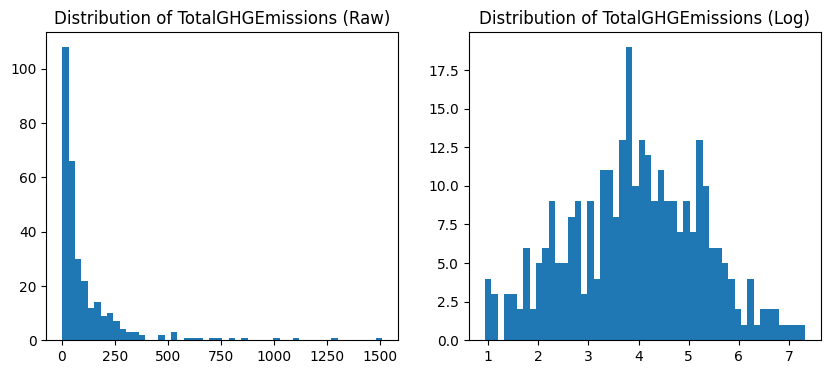

In [61]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y_test_ghg, bins=50)
plt.title('Distribution of TotalGHGEmissions (Raw)')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(y_test_ghg), bins=50)  # log1p avoids log(0)
plt.title('Distribution of TotalGHGEmissions (Log)')
plt.show()

In [62]:
# Lasso for GHG (log scale) - create NEW GridSearchCV
lasso_grid_log = GridSearchCV(Lasso(), lasso_params, cv=10, scoring='r2', n_jobs=-1)

# Transform to log space
y_train_ghg_log = np.log1p(y_train_ghg)
y_test_ghg_log = np.log1p(y_test_ghg)

# Fit on log-transformed target
lasso_grid_log.fit(X_train_scaled, y_train_ghg_log)

# Predict in log space
y_pred_ghg_log = lasso_grid_log.predict(X_test_scaled)

# Evaluate in log space
r2_log_space = r2_score(y_test_ghg_log, y_pred_ghg_log)

# Transform back to original scale
y_pred_ghg_from_log = np.expm1(y_pred_ghg_log)

# Evaluate in original scale
r2_log_model = r2_score(y_test_ghg, y_pred_ghg_from_log)
mae_log_model = mean_absolute_error(y_test_ghg, y_pred_ghg_from_log)
rmse_log_model = np.sqrt(mean_squared_error(y_test_ghg, y_pred_ghg_from_log))

print(f"Log Model - R² in log space: {r2_log_space:.3f}")
print(f"Log Model - Test R² (back-transformed): {r2_log_model:.3f}, MAE: {mae_log_model:.0f}, RMSE: {rmse_log_model:.0f}")

# Compare
print(f"\nImprovement from log transformation:")
print(f"R² change: {(r2_log_model - r2_original):.3f}")
print(f"MAE change: {(mae_log_model - mae_original):.0f}")
print(f"RMSE change: {(rmse_log_model - rmse_original):.0f}")

Log Model - R² in log space: 0.341
Log Model - Test R² (back-transformed): -266.474, MAE: 256, RMSE: 3069

Improvement from log transformation:
R² change: -267.038
MAE change: 185
RMSE change: 2945


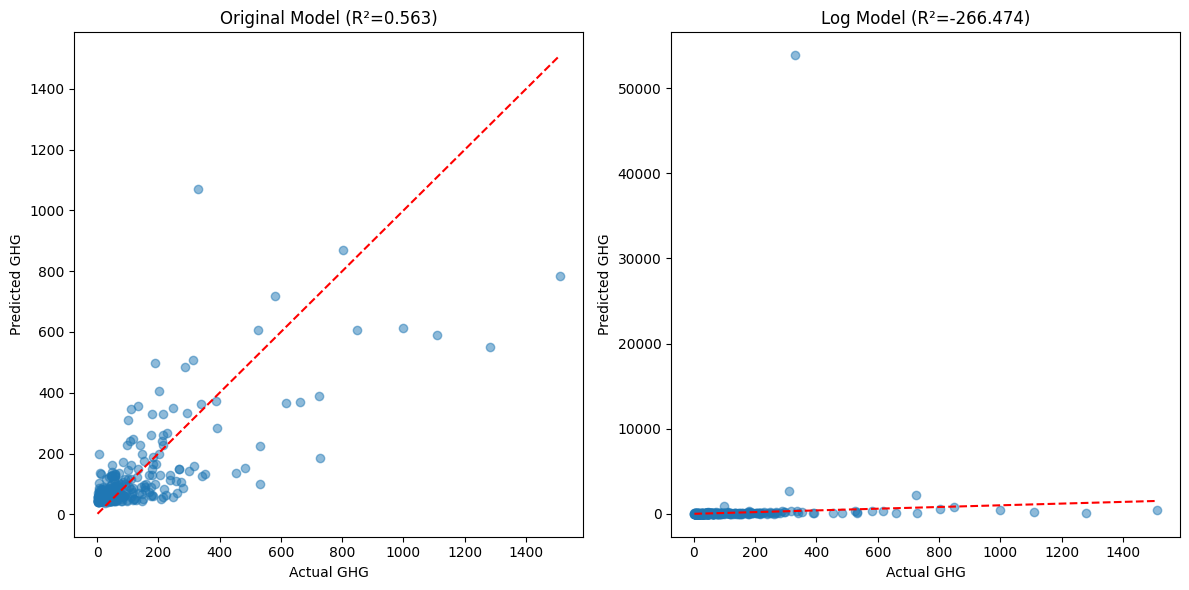

In [63]:
plt.figure(figsize=(12, 6))

# Original model
plt.subplot(1, 2, 1)
plt.scatter(y_test_ghg, y_pred_ghg, alpha=0.5)
plt.plot([y_test_ghg.min(), y_test_ghg.max()],
         [y_test_ghg.min(), y_test_ghg.max()], 'r--')
plt.xlabel('Actual GHG')
plt.ylabel('Predicted GHG')
plt.title(f'Original Model (R²={r2_original:.3f})')

# Log model (back-transformed)
plt.subplot(1, 2, 2)
plt.scatter(y_test_ghg, y_pred_ghg_from_log, alpha=0.5)
plt.plot([y_test_ghg.min(), y_test_ghg.max()],
         [y_test_ghg.min(), y_test_ghg.max()], 'r--')
plt.xlabel('Actual GHG')
plt.ylabel('Predicted GHG')
plt.title(f'Log Model (R²={r2_log_model:.3f})')

plt.tight_layout()
plt.show()

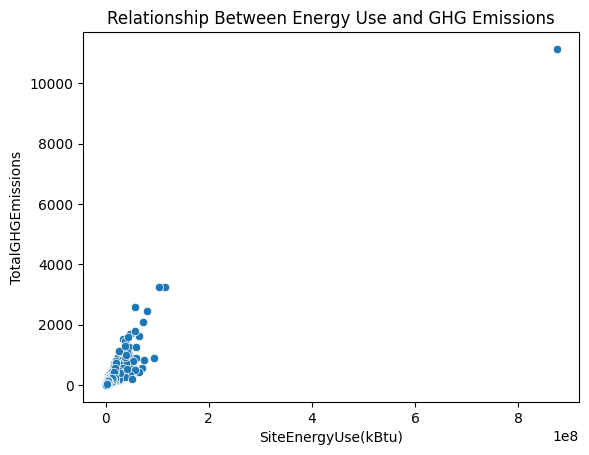

In [64]:
sns.scatterplot(x=df['SiteEnergyUse(kBtu)'], y=df['TotalGHGEmissions'])
plt.title("Relationship Between Energy Use and GHG Emissions")
plt.show()